# Time-aware forecasting of firm-level credit demand — v3

**Research question.** How responsive is firms' credit demand to expectations about the
economy, and can text-based sentiment indicators from public reports improve forecasts?

This version rebuilds the modelling and evaluation layer of the previous notebook. The
data pipeline was already sound; the inferential layer was missing. The changes below are
grouped by the problem they solve.

### 1. Uncertainty quantification (the main gap)
* The survey and text blocks are **constant within a year**. Their effective sample size is
  the number of years (10 in development, 3 usable test years), *not* 1.7 million firm-years.
  Every claim about them is now accompanied by an uncertainty statement.
* **Diebold–Mariano tests** on the loss differential, clustered on the evaluation year, with
  a `t(G-1)` reference distribution — the honest small-cluster correction.
* **Block bootstrap over years** for confidence intervals on ΔRMSE.
* **Extended rolling-origin evaluation** (Section 12): every year from `EVAL_FIRST_YEAR`
  onwards is an out-of-time origin, refit on prior data only. This raises the number of
  year-clusters from 3 to ~8, which is the only way to get usable power for the
  survey/text question. Design follows Gu, Kelly & Xiu (2020, *RFS*).

### 2. Model selection discipline
* Hyperparameters and the feature-block decision are made **entirely on development-period
  folds (validation years ≤ 2019)**, then frozen. Section 15 runs the 2020-onwards block once.
* Ablation hyperparameters are now **re-tuned per feature block** instead of inherited from
  the full block.
* Reporting is structured so the CV-selected specification leads and the test confirms or
  refutes it — not the other way round.

### 3. Tuning
* **Widened grids** with an automatic boundary check (Ridge previously selected α = 100, the
  maximum of its grid).
* **One-standard-error rule** (ISL §6.2 / ESL §7.10) for the linear penalty.
* **`n_estimators` is a tuned hyperparameter** scored on the validation year, replacing early
  stopping *on the scoring fold*. This removes the optimism bias and matches the lecture's
  prescription to tune λ and B jointly by cross-validation.
* **Convergence audit** for the coordinate-descent models — the previous ElasticNet
  coefficient table was not a valid optimum.

### 4. Preprocessing
* **`QuantileWinsorizer` fitted inside the pipeline** on training folds only. Leakage-free
  *and* it tames the tails (`solvency_ratio_clean` previously reached −734,202).
* **Dummies are scaled too**, so a single α shrinks all coefficients on a comparable scale
  (ESL §3.4 — the ridge/lasso penalty is not scale-invariant).
* **Explicit `"Missing"` category** instead of imputing the modal sector.
* **Shared missing indicators**, so the linear and tree models see identical information.

### 5. Design and data
* **Firm-level subsampling** (all years of a random firm subset) instead of row-level, which
  preserves the panel and permits firm-clustered inference.
* **Thin years excluded** from headline results. 2023 has ~1,685 rows against ~200,000
  elsewhere because it needs FY2024 accounts.
* **`R2_oos_within_year`** reported alongside the headline R², separating cross-sectional
  skill from tracking the shifting unconditional level.
* **MAE reported everywhere** — no model previously beat the mean benchmark on absolute loss.
* **Sensitivity run** (Section 19) excluding calendar-time proxies (`years_in_panel`,
  first-year missing indicators).

### 6. New analyses
* **Random forest** on the same folds (Section 11).
* **RQ2**: sentiment × firm-characteristic interactions and subgroup ablations by size,
  leverage and sector (Section 14).
* **Partial dependence** for the sentiment indicators (Section 16) — the only tool here that
  answers *how responsive* rather than *is it important*.
* **Robustness** (Section 17): ΔNCLI scaled by lagged assets, robust losses, and a
  classification framing with AUC and decile lift.

## How to run
1. Set `DATA_PATH` in Section 1.
2. Run with `QUICK_MODE = True` end to end first to verify the pipeline.
3. For the final paper: restart the kernel, set `QUICK_MODE = False`, run all cells, and do
   not change the specification after Section 15 has been executed.

## 1. Imports and configuration

In [1]:
from __future__ import annotations

import gc
import json
import os
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
from scipy import stats

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.exceptions import ConvergenceWarning
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.linear_model import ElasticNet, Lasso, Ridge
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GridSearchCV, ParameterSampler
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

import xgboost as xgb

warnings.filterwarnings("ignore", category=FutureWarning)
# ConvergenceWarning is deliberately NOT suppressed - Section 9 audits it explicitly.
pd.set_option("display.max_columns", 140)
pd.set_option("display.width", 200)

# -----------------------------------------------------------------------------
# Paths
# -----------------------------------------------------------------------------
DATA_PATH = Path("data/model_input/analysis_panel.parquet")
OUTPUT_DIR = Path("outputs/time_aware_model_report_v3")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# -----------------------------------------------------------------------------
# Evaluation design
# -----------------------------------------------------------------------------
RANDOM_STATE = 42
YEAR_COL = "closdate_year"
ID_COL = "idnr"
TARGET = "ncliGrowthNextYear"

TEST_START_YEAR = 2020          # frozen held-out block starts here
FIRST_VALIDATION_YEAR = 2015    # first development validation fold
LAST_VALIDATION_YEAR = 2019     # last development validation fold
EVAL_FIRST_YEAR = 2015          # first rolling-origin evaluation year
MIN_YEAR_OBSERVATIONS = 10_000  # years thinner than this are excluded from headline results

# Winsorization quantiles, applied INSIDE the pipeline on training folds only.
WINSOR_LOWER, WINSOR_UPPER = 0.01, 0.99

# Coordinate descent on the near-collinear survey block does not converge at very small
# penalties: it simply burns iterations. See the diagnostic in Section 10. Bounding
# max_iter keeps runtime finite and lets the convergence audit report the problem
# instead of hiding it behind hours of compute.
LINEAR_MAX_ITER = 5_000

# Optional: replace the survey block with its leading principal components inside the
# LINEAR pipeline only (fitted per fold). This is the textbook fix for a rank-deficient
# design matrix (ESL 3.5) and removes the collinearity outright. None = keep the raw
# series, which preserves coefficient interpretability. Tree models are unaffected.
SURVEY_PCA_COMPONENTS = None

# Features that are near-deterministic proxies for calendar time. Section 19 reruns
# the headline comparison without them.
TIME_PROXY_FEATURES = ["years_in_panel"]

# -----------------------------------------------------------------------------
# Runtime controls
# -----------------------------------------------------------------------------
QUICK_MODE = True

# Subsampling is at FIRM level (all years of a sampled firm are kept), so the panel
# structure and firm-clustered inference survive.
SCREEN_ROWS_PER_YEAR   = 8_000  if QUICK_MODE else 20_000   # stage-1 hyperparameter screen
TUNING_ROWS_PER_YEAR   = 15_000 if QUICK_MODE else 50_000   # stage-2 refinement
EVAL_ROWS_PER_YEAR     = 15_000 if QUICK_MODE else 60_000   # rolling-origin engine
FINAL_ROWS_PER_YEAR    = 15_000 if QUICK_MODE else None     # None = all rows for the frozen test

SCREEN_TRIALS   = 8    if QUICK_MODE else 30   # random-search candidates, stage 1
REFINE_TOP_K    = 3    if QUICK_MODE else 6    # candidates promoted to stage 2
RETUNE_PER_BLOCK = True                        # re-tune hyperparameters for every feature block
N_BOOTSTRAP     = 500  if QUICK_MODE else 2_000
PDP_SAMPLE_SIZE = 5_000 if QUICK_MODE else 30_000
PERMUTATION_SAMPLE_SIZE = 10_000 if QUICK_MODE else 50_000
PERMUTATION_REPEATS = 3

N_JOBS = max(1, min(4, os.cpu_count() or 1))
LINEAR_SEARCH_N_JOBS = 1  # keep at 1: the panel is large and joblib duplicates it

# Set True only after the specification is frozen on development-period folds.
RUN_FINAL_TEST = True
SAVE_MODELS = False

print(json.dumps({
    "quick_mode": QUICK_MODE,
    "screen_rows_per_year": SCREEN_ROWS_PER_YEAR,
    "tuning_rows_per_year": TUNING_ROWS_PER_YEAR,
    "eval_rows_per_year": EVAL_ROWS_PER_YEAR,
    "screen_trials": SCREEN_TRIALS,
    "refine_top_k": REFINE_TOP_K,
    "retune_per_block": RETUNE_PER_BLOCK,
    "threads": N_JOBS,
    "run_final_test": RUN_FINAL_TEST,
}, indent=2))

{
  "quick_mode": true,
  "screen_rows_per_year": 8000,
  "tuning_rows_per_year": 15000,
  "eval_rows_per_year": 15000,
  "screen_trials": 8,
  "refine_top_k": 3,
  "retune_per_block": true,
  "threads": 4,
  "run_final_test": true
}


### Compute budget

The expensive cells are Section 9–11 (tuning) and Section 12 (rolling-origin evaluation).
Subsampling is deliberate: hyperparameter selection and the inference engine run on a firm-level
subsample, while the frozen held-out test in Section 15 uses every observation. The
consequence — hyperparameters calibrated on ~*n* rows are applied at a larger *n* — is checked
in Section 15 by comparing the subsampled and full-data test scores.

## 2. Reusable components

In [2]:
# =============================================================================
# 2.1 Winsorizer fitted inside the pipeline (training folds only)
# =============================================================================
class QuantileWinsorizer(BaseEstimator, TransformerMixin):
    """Clip numeric columns at quantiles learned on the training fold.

    Replaces the previous choice between (a) full-sample winsorization, which leaks
    test-period information into training, and (b) no winsorization, which left ratios
    with values in the hundreds of thousands. Fitting inside the pipeline gives the
    benefit without the leakage.
    """

    def __init__(self, lower_quantile: float = 0.01, upper_quantile: float = 0.99):
        self.lower_quantile = lower_quantile
        self.upper_quantile = upper_quantile

    @staticmethod
    def _as_array(X) -> np.ndarray:
        if hasattr(X, "to_numpy"):
            return X.to_numpy(dtype=np.float32, copy=True)
        return np.asarray(X, dtype=np.float32)

    def fit(self, X, y=None):
        values = self._as_array(X)
        self.n_features_in_ = values.shape[1]
        if hasattr(X, "columns"):
            self.feature_names_in_ = np.asarray(X.columns, dtype=object)
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=RuntimeWarning)
            lower = np.nanquantile(values, self.lower_quantile, axis=0)
            upper = np.nanquantile(values, self.upper_quantile, axis=0)
        self.lower_bounds_ = np.where(np.isfinite(lower), lower, -np.inf).astype(np.float32)
        self.upper_bounds_ = np.where(np.isfinite(upper), upper, np.inf).astype(np.float32)
        return self

    def transform(self, X):
        return np.clip(self._as_array(X), self.lower_bounds_, self.upper_bounds_)

    def get_feature_names_out(self, input_features=None):
        if input_features is not None:
            return np.asarray(input_features, dtype=object)
        if hasattr(self, "feature_names_in_"):
            return self.feature_names_in_
        return np.asarray([f"x{i}" for i in range(self.n_features_in_)], dtype=object)


# =============================================================================
# 2.2 Deterministic FIRM-level sampling (preserves each firm's full history)
# =============================================================================
def firm_hash_uniform(ids: pd.Series) -> np.ndarray:
    hashed = pd.util.hash_pandas_object(ids.astype(str), index=False).to_numpy(dtype="uint64")
    return (hashed % np.uint64(10_000_019)).astype(np.float64) / 10_000_019.0


def sample_firms_to_target(frame: pd.DataFrame, target_rows_per_year: int | None) -> pd.DataFrame:
    """Keep a deterministic random subset of firms, with all of their years."""
    if target_rows_per_year is None:
        return frame.copy()
    busiest_year = int(frame[YEAR_COL].value_counts().max())
    if busiest_year <= target_rows_per_year:
        return frame.copy()
    fraction = target_rows_per_year / busiest_year
    return frame.loc[firm_hash_uniform(frame[ID_COL]) < fraction].copy()


# =============================================================================
# 2.3 Metrics
# =============================================================================
def regression_metrics(y_true, y_pred, baseline_value: float, years=None) -> dict:
    """RMSE, MAE, R2_oos against a fixed baseline, and R2_oos against each year's own mean.

    `R2_oos_within_year` is the important addition: the unconditional level of the target
    shifts across periods, so part of the headline R2_oos is level tracking rather than
    cross-sectional discrimination between firms.
    """
    yt = np.asarray(y_true, dtype=float)
    yp = np.asarray(y_pred, dtype=float)
    valid = np.isfinite(yt) & np.isfinite(yp)
    yt, yp = yt[valid], yp[valid]
    if len(yt) == 0:
        return {"RMSE": np.nan, "MAE": np.nan, "R2_oos": np.nan,
                "R2_oos_within_year": np.nan, "n": 0}

    residual = yt - yp
    sse = float(np.sum(residual ** 2))
    baseline_sse = float(np.sum((yt - baseline_value) ** 2))

    within_year = np.nan
    if years is not None:
        yr = np.asarray(years)[valid]
        year_means = pd.Series(yt).groupby(pd.Series(yr)).transform("mean").to_numpy()
        within_sse = float(np.sum((yt - year_means) ** 2))
        if within_sse > 0:
            within_year = float(1 - sse / within_sse)

    return {
        "RMSE": float(np.sqrt(sse / len(yt))),
        "MAE": float(np.mean(np.abs(residual))),
        "R2_oos": float(1 - sse / baseline_sse) if baseline_sse > 0 else np.nan,
        "R2_oos_within_year": within_year,
        "n": int(len(yt)),
    }


# =============================================================================
# 2.4 Forecast comparison: Diebold-Mariano clustered on the evaluation year
# =============================================================================
def diebold_mariano(y_true, pred_a, pred_b, groups, loss="squared",
                    equal_weight_groups=True) -> dict:
    """Test H0: forecasts a and b have equal expected loss.

    The macro and text blocks vary only across years, so the year is the unit of
    independent variation. Clustering on the year and using t(G-1) reflects the real
    effective sample size instead of the 600,000 firm-years that would otherwise imply
    absurd precision. Negative `mean_loss_differential` means a is better than b.
    """
    yt, pa, pb = (np.asarray(v, dtype=float) for v in (y_true, pred_a, pred_b))
    grp = np.asarray(groups)
    valid = np.isfinite(yt) & np.isfinite(pa) & np.isfinite(pb)
    yt, pa, pb, grp = yt[valid], pa[valid], pb[valid], grp[valid]

    if loss == "squared":
        differential = (yt - pa) ** 2 - (yt - pb) ** 2
    elif loss == "absolute":
        differential = np.abs(yt - pa) - np.abs(yt - pb)
    else:
        raise ValueError("loss must be 'squared' or 'absolute'")

    group_stats = pd.DataFrame({"d": differential, "g": grp}).groupby("g")["d"].agg(["mean", "size"])
    n_groups = len(group_stats)
    empty = {"mean_loss_differential": float(np.mean(differential)), "t_stat": np.nan,
             "p_value": np.nan, "n_groups": n_groups, "ci_low": np.nan, "ci_high": np.nan}
    if n_groups < 2:
        return empty

    group_means = group_stats["mean"].to_numpy()
    point = (float(group_means.mean()) if equal_weight_groups
             else float(np.average(group_means, weights=group_stats["size"].to_numpy())))
    standard_error = float(np.std(group_means, ddof=1) / np.sqrt(n_groups))
    if standard_error == 0:
        return empty

    t_stat = point / standard_error
    critical = float(stats.t.ppf(0.975, df=n_groups - 1))
    return {
        "mean_loss_differential": point,
        "t_stat": float(t_stat),
        "p_value": float(2 * stats.t.sf(abs(t_stat), df=n_groups - 1)),
        "n_groups": int(n_groups),
        "ci_low": point - critical * standard_error,
        "ci_high": point + critical * standard_error,
    }


def block_bootstrap_delta_rmse(y_true, pred_a, pred_b, groups,
                               n_boot=2000, random_state=RANDOM_STATE) -> dict:
    """Resample whole years with replacement; CI for RMSE(a) - RMSE(b)."""
    yt, pa, pb = (np.asarray(v, dtype=float) for v in (y_true, pred_a, pred_b))
    grp = np.asarray(groups)
    valid = np.isfinite(yt) & np.isfinite(pa) & np.isfinite(pb)
    yt, pa, pb, grp = yt[valid], pa[valid], pb[valid], grp[valid]

    unique_groups = np.unique(grp)
    sums = {}
    for g in unique_groups:
        mask = grp == g
        sums[g] = (float(np.sum((yt[mask] - pa[mask]) ** 2)),
                   float(np.sum((yt[mask] - pb[mask]) ** 2)),
                   int(mask.sum()))

    def delta(selection):
        sse_a = sum(sums[g][0] for g in selection)
        sse_b = sum(sums[g][1] for g in selection)
        n = sum(sums[g][2] for g in selection)
        return float(np.sqrt(sse_a / n) - np.sqrt(sse_b / n))

    rng = np.random.default_rng(random_state)
    draws = np.array([delta(rng.choice(unique_groups, size=len(unique_groups), replace=True))
                      for _ in range(n_boot)])
    return {
        "delta_rmse": delta(unique_groups),
        "ci_low": float(np.percentile(draws, 2.5)),
        "ci_high": float(np.percentile(draws, 97.5)),
        "share_favouring_a": float(np.mean(draws < 0)),
        "n_groups": int(len(unique_groups)),
    }


# =============================================================================
# 2.5 One-standard-error rule and grid-boundary check
# =============================================================================
def select_one_standard_error(cv_results, complexity_key, n_splits, higher_is_simpler=True):
    """Most regularized candidate within one standard error of the best CV score.

    ISL section 6.2 / ESL section 7.10. The CV surface here is very flat, so picking the
    literal minimum over-reads differences in the fourth decimal and produced a
    near-unpenalized linear model that extrapolated badly out of time.
    """
    results = pd.DataFrame(cv_results)
    best_index = int(results["mean_test_score"].idxmax())
    best_score = float(results.loc[best_index, "mean_test_score"])
    one_se = float(results.loc[best_index, "std_test_score"]) / np.sqrt(n_splits)

    eligible = results[results["mean_test_score"] >= best_score - one_se].copy()
    eligible["complexity"] = eligible["params"].apply(lambda p: float(p[complexity_key]))
    eligible = eligible.sort_values("complexity", ascending=not higher_is_simpler)
    chosen = eligible.iloc[0]

    return dict(chosen["params"]), {
        "best_rmse": -best_score,
        "one_se": one_se,
        "chosen_rmse": -float(chosen["mean_test_score"]),
        "n_within_one_se": int(len(eligible)),
        "best_params": results.loc[best_index, "params"],
    }


def check_grid_boundaries(selected: dict, grid: dict, label: str = "") -> list[str]:
    """Flag selected hyperparameters sitting on the edge of their search grid."""
    messages = []
    for key, values in grid.items():
        if key not in selected:
            continue
        numeric = [v for v in np.atleast_1d(values) if isinstance(v, (int, float, np.number))]
        value = selected[key]
        if len(numeric) < 2 or not isinstance(value, (int, float, np.number)):
            continue
        if np.isclose(float(value), float(min(numeric))):
            messages.append(f"[{label}] {key}={value} is at the LOWER grid edge - widen downwards.")
        if np.isclose(float(value), float(max(numeric))):
            messages.append(f"[{label}] {key}={value} is at the UPPER grid edge - widen upwards.")
    return messages


# =============================================================================
# 2.6 Time-ordered folds
# =============================================================================
def expanding_window_folds(frame, first_validation_year, last_validation_year):
    """Expanding-origin folds: train on everything strictly before the validation year."""
    year_values = frame[YEAR_COL].to_numpy()
    folds, fold_years = [], []
    for validation_year in sorted(frame[YEAR_COL].dropna().unique()):
        if not (first_validation_year <= validation_year <= last_validation_year):
            continue
        train_idx = np.flatnonzero(year_values < validation_year)
        validation_idx = np.flatnonzero(year_values == validation_year)
        if len(train_idx) and len(validation_idx):
            folds.append((train_idx, validation_idx))
            fold_years.append(int(validation_year))
    return folds, fold_years


print("Reusable components defined.")

Reusable components defined.


## 3. Load the panel

In [3]:
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Could not find {DATA_PATH.resolve()}. Adjust DATA_PATH in Section 1.")

DROP_COLS_AT_LOAD = ["name", "dateinc", "report_date"]
schema_cols = pq.ParquetFile(DATA_PATH).schema_arrow.names
usecols = [c for c in schema_cols if c not in DROP_COLS_AT_LOAD]

df = pd.read_parquet(DATA_PATH, columns=usecols)

required = {ID_COL, YEAR_COL, TARGET}
missing_required = sorted(required.difference(df.columns))
if missing_required:
    raise KeyError(f"Required columns are missing: {missing_required}")

float64_cols = df.select_dtypes(include="float64").columns
df[float64_cols] = df[float64_cols].astype("float32")

df[YEAR_COL] = pd.to_numeric(df[YEAR_COL], errors="coerce").astype("Int16")
df = df.dropna(subset=[ID_COL, YEAR_COL, TARGET]).copy()
df[YEAR_COL] = df[YEAR_COL].astype(int)

gc.collect()
print(f"Shape: {df.shape}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1e9:.2f} GB")

Shape: (1745282, 77)
Memory usage: 0.69 GB


## 4. Data integrity and panel descriptives

In [4]:
# -----------------------------------------------------------------------------
# 4.1 Panel structure. These numbers belong in the "Data: Descriptives" slide and
#     were absent from the previous version.
# -----------------------------------------------------------------------------
observations_per_firm = df.groupby(ID_COL, sort=False).size()
panel_summary = pd.Series({
    "firm_years": len(df),
    "unique_firms": df[ID_COL].nunique(),
    "mean_years_per_firm": round(float(observations_per_firm.mean()), 2),
    "median_years_per_firm": float(observations_per_firm.median()),
    "firms_with_one_year_only": int((observations_per_firm == 1).sum()),
    "duplicate_firm_years": int(df.duplicated([ID_COL, YEAR_COL]).sum()),
}).to_frame("value")
display(panel_summary)

year_counts = df[YEAR_COL].value_counts().sort_index().to_frame("n")
year_counts["share_of_panel"] = (year_counts["n"] / len(df)).round(4)
year_counts["thin_year"] = year_counts["n"] < MIN_YEAR_OBSERVATIONS
display(year_counts)

THIN_YEARS = sorted(year_counts.index[year_counts["thin_year"]].tolist())
if THIN_YEARS:
    print(
        f"\nThin years excluded from headline results: {THIN_YEARS}\n"
        "  A fiscal year t needs FY t+1 accounts to form the outcome, so the most recent\n"
        "  year is a small, heavily selected subsample of early filers. Reporting it\n"
        "  alongside years with 200,000 observations invites over-reading."
    )

# -----------------------------------------------------------------------------
# 4.2 Firm overlap between development and test - relevant for clustering.
# -----------------------------------------------------------------------------
dev_firms = set(df.loc[df[YEAR_COL] < TEST_START_YEAR, ID_COL].unique())
test_firms = set(df.loc[df[YEAR_COL] >= TEST_START_YEAR, ID_COL].unique())
print(f"\nFirms in development: {len(dev_firms):,}")
print(f"Firms in test: {len(test_firms):,}")
print(f"Firms in both (repeat observations across the split): {len(dev_firms & test_firms):,}")
print(f"Firms appearing only in the test period: {len(test_firms - dev_firms):,}")

# -----------------------------------------------------------------------------
# 4.3 Accounting identity audit (diagnostic only, does not alter the data)
# -----------------------------------------------------------------------------
def relative_gap(a: pd.Series, b: pd.Series) -> pd.Series:
    denominator = np.maximum(np.maximum(a.abs(), b.abs()), 1.0)
    return (a - b).abs() / denominator

identities = [
    ("toas = tshf", {"toas", "tshf"}, lambda d: (d["toas"], d["tshf"])),
    ("fias + cuas = toas", {"fias", "cuas", "toas"}, lambda d: (d["fias"] + d["cuas"], d["toas"])),
    ("shfd + ncli + culi = tshf", {"shfd", "ncli", "culi", "tshf"},
     lambda d: (d["shfd"] + d["ncli"] + d["culi"], d["tshf"])),
]
audit_rows = []
for name, needed, getter in identities:
    if needed.issubset(df.columns):
        left, right = getter(df)
        gap = relative_gap(left, right)
        audit_rows.append({"identity": name,
                           "median_relative_gap": float(gap.median()),
                           "p99_relative_gap": float(gap.quantile(0.99)),
                           "share_gap_gt_1pct": float((gap > 0.01).mean())})
if audit_rows:
    display(pd.DataFrame(audit_rows))

,value
firm_years,1745282.00
unique_firms,285318.00
mean_years_per_firm,6.12
median_years_per_firm,7.00
firms_with_one_year_only,21360.00
duplicate_firm_years,0.00


,n,share_of_panel,thin_year
closdate_year,,,
2010,13132,0.0075,False
2011,12950,0.0074,False
2012,21695,0.0124,False
2013,39951,0.0229,False
2014,138297,0.0792,False
2015,145276,0.0832,False
2016,149169,0.0855,False
2017,190184,0.1090,False
2018,201605,0.1155,False



Thin years excluded from headline results: [2023]
  A fiscal year t needs FY t+1 accounts to form the outcome, so the most recent
  year is a small, heavily selected subsample of early filers. Reporting it
  alongside years with 200,000 observations invites over-reading.

Firms in development: 248,538
Firms in test: 275,052
Firms in both (repeat observations across the split): 238,272
Firms appearing only in the test period: 36,780


,identity,median_relative_gap,p99_relative_gap,share_gap_gt_1pct
0,toas = tshf,0.0,0.000000,0.000000
1,fias + cuas = toas,0.0,0.000002,0.000158
2,shfd + ncli + culi = tshf,0.0,0.000004,0.000002


### Missingness drift across time

Missingness of the lag-based features is mechanically "this is the firm's first year in the
panel". Panel entry rates change dramatically over the sample (coverage grows from ~13,000
firms in 2010 to ~220,000 in 2020), so these indicators partly encode *which year it is*.
That relationship does not extrapolate out of time. The plot below is the diagnostic; Section
19 reruns the headline comparison with the calendar-time proxies removed.

,ncliGrowthThisYear,empl,years_in_panel,firm_age
closdate_year,,,,
2010,1.000,0.940,0.0,0.047
2011,0.586,0.906,0.0,0.057
2012,0.609,0.874,0.0,0.072
2013,0.764,0.835,0.0,0.083
2014,0.776,0.849,0.0,0.087
2015,0.137,0.837,0.0,0.085
2016,0.081,0.673,0.0,0.081
2017,0.114,0.447,0.0,0.077
2018,0.058,0.377,0.0,0.075


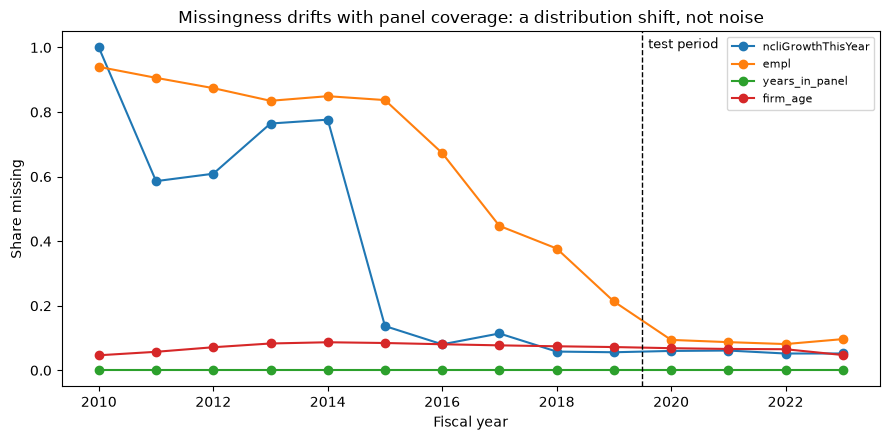

In [5]:
lag_dependent = [c for c in ["ncliGrowthThisYear", "log_toas_change_clean",
                             "cash_change_to_lagged_assets", "ncli_growth_volatility_3y",
                             "empl", "years_in_panel", "firm_age"] if c in df.columns]

if lag_dependent:
    missing_by_year = df.groupby(YEAR_COL)[lag_dependent].apply(lambda g: g.isna().mean())
    display(missing_by_year.round(3))

    fig, ax = plt.subplots(figsize=(9, 4.5))
    for column in missing_by_year.columns:
        ax.plot(missing_by_year.index, missing_by_year[column], marker="o", label=column)
    ax.axvline(TEST_START_YEAR - 0.5, color="black", linestyle="--", linewidth=1)
    ax.text(TEST_START_YEAR - 0.4, ax.get_ylim()[1] * 0.95, "test period", fontsize=9)
    ax.set_xlabel("Fiscal year"); ax.set_ylabel("Share missing")
    ax.set_title("Missingness drifts with panel coverage: a distribution shift, not noise")
    ax.legend(fontsize=8); plt.tight_layout(); plt.show()

## 5. Leakage-safe feature engineering

Unchanged from the previous version except for four additions:

1. **Shared missing indicators.** Previously the linear pipeline received
   `SimpleImputer(add_indicator=True)` while XGBoost used its own learned default direction.
   The two model families therefore saw different information, which contaminates the
   comparison. Indicators are now built once as real columns, selected on **development-period
   missingness only**, and handed to every model.
2. **Alternative outcome** `ncli_change_to_lagged_assets`, reconstructed from the raw `ncli`
   level via a within-firm forward shift. The provided target is trimmed at |growth| < 1,
   which removes exactly the firms taking on large new long-term borrowing — the events
   NRW.BANK cares about. Used as a robustness check in Section 16.
3. **Sentiment × firm-characteristic interactions** for RQ2. The macro series is centred on its
   **development-period** mean (a training-only statistic) so the interaction is interpretable
   as "response at average sentiment plus deviation".
4. Macro annual aggregates are now computed on **development years only** and mapped to all
   years, so no test-period value influences the centring constants.

In [6]:
def safe_ratio(numerator, denominator, *, require_positive_denominator=True) -> pd.Series:
    numerator = pd.to_numeric(numerator, errors="coerce")
    denominator = pd.to_numeric(denominator, errors="coerce")
    valid = numerator.notna() & denominator.notna()
    valid &= denominator > 0 if require_positive_denominator else denominator != 0
    out = pd.Series(np.nan, index=numerator.index, dtype="float32")
    out.loc[valid] = (numerator.loc[valid] / denominator.loc[valid]).astype("float32")
    return out.replace([np.inf, -np.inf], np.nan)


# Sort once so every lagged feature uses only year t and earlier.
df = df.sort_values([ID_COL, YEAR_COL]).copy()
firm_group = df.groupby(ID_COL, sort=False)
lag_year = firm_group[YEAR_COL].shift(1)
lead_year = firm_group[YEAR_COL].shift(-1)
consecutive_back = (df[YEAR_COL] - lag_year).eq(1)
consecutive_forward = (lead_year - df[YEAR_COL]).eq(1)

# -----------------------------------------------------------------------------
# 5.1 Balance-sheet ratios. Extreme values are handled by the in-pipeline
#     winsorizer (Section 2.1), not by dropping observations here.
# -----------------------------------------------------------------------------
if {"cuas", "culi"}.issubset(df.columns):
    df["current_ratio_clean"] = safe_ratio(df["cuas"], df["culi"])
    df["log1p_current_ratio_clean"] = np.log1p(df["current_ratio_clean"].clip(lower=0)).astype("float32")

if {"cuas", "stok", "culi"}.issubset(df.columns):
    df["quick_ratio_clean"] = safe_ratio(df["cuas"] - df["stok"], df["culi"])
    df["log1p_quick_ratio_clean"] = np.log1p(df["quick_ratio_clean"].clip(lower=0)).astype("float32")

if {"shfd", "toas"}.issubset(df.columns):
    df["solvency_ratio_clean"] = safe_ratio(df["shfd"], df["toas"])

if {"ncli", "loan", "shfd"}.issubset(df.columns):
    df["gearing_ratio_clean"] = safe_ratio(df["ncli"] + df["loan"], df["shfd"])
    df["log1p_gearing_ratio_clean"] = np.log1p(df["gearing_ratio_clean"].clip(lower=0)).astype("float32")

if {"ncli", "culi", "toas"}.issubset(df.columns):
    df["liabilities_to_assets"] = safe_ratio(df["ncli"] + df["culi"], df["toas"])

if {"wkca", "toas"}.issubset(df.columns):
    df["working_capital_to_assets"] = safe_ratio(df["wkca"], df["toas"])

for numerator, denominator, name in [
    ("stok", "cuas", "inventory_share_current_assets"),
    ("debt", "cuas", "receivables_share_current_assets"),
    ("cash", "toas", "cash_to_assets"),
    ("fias", "toas", "fixed_assets_share"),
    ("ltdb", "ncli", "ltdb_share_of_ncli"),
]:
    if {numerator, denominator}.issubset(df.columns):
        valid = (df[denominator] > 0) & (df[numerator] >= 0) & (df[numerator] <= df[denominator])
        df[name] = np.where(valid, df[numerator] / df[denominator], np.nan).astype("float32")

# -----------------------------------------------------------------------------
# 5.2 Stable within-firm changes
# -----------------------------------------------------------------------------
if "log_toas" not in df.columns and "toas" in df.columns:
    df["log_toas"] = np.log1p(df["toas"].clip(lower=0)).astype("float32")
if "log_empl" not in df.columns and "empl" in df.columns:
    df["log_empl"] = np.log1p(df["empl"].clip(lower=0)).astype("float32")

if "log_toas" in df.columns:
    df["log_toas_change_clean"] = np.where(
        consecutive_back, df["log_toas"] - firm_group["log_toas"].shift(1), np.nan).astype("float32")

if {"cash", "toas"}.issubset(df.columns):
    lag_toas = firm_group["toas"].shift(1)
    df["cash_change_to_lagged_assets"] = np.where(
        consecutive_back & lag_toas.gt(0),
        (df["cash"] - firm_group["cash"].shift(1)) / lag_toas, np.nan).astype("float32")

if "ncliGrowthThisYear" in df.columns:
    df["ncli_growth_volatility_3y"] = (
        df.groupby(ID_COL, sort=False)["ncliGrowthThisYear"]
          .rolling(window=3, min_periods=2).std()
          .reset_index(level=0, drop=True).astype("float32")
    )

if "naics_2digit" not in df.columns and "naics_core_code" in df.columns:
    df["naics_2digit"] = df["naics_core_code"].astype(str).str[:2]

# -----------------------------------------------------------------------------
# 5.3 Alternative outcome: change in NCLI scaled by lagged total assets.
#     Reconstructed from the raw level so it is not subject to the |growth| < 1 trim
#     that removes large new borrowing events.
# -----------------------------------------------------------------------------
ALT_TARGET = "ncli_change_to_lagged_assets"
if {"ncli", "toas"}.issubset(df.columns):
    ncli_next = firm_group["ncli"].shift(-1)
    df[ALT_TARGET] = np.where(
        consecutive_forward & df["toas"].gt(0),
        (ncli_next - df["ncli"]) / df["toas"], np.nan).astype("float32")

    # Firms with near-zero total assets reintroduce exactly the explosive tails that the
    # +/-100% trim was designed to remove on the primary outcome - the problem simply
    # moves to a different denominator. Two guards, both estimated on development years
    # only so that no test-period value influences them:
    #   (1) require the denominator to clear the 1st percentile of positive total assets;
    #   (2) winsorize the resulting ratio at its 1st/99th percentile.
    development_rows = df[YEAR_COL] < TEST_START_YEAR
    toas_floor = float(df.loc[development_rows & df["toas"].gt(0), "toas"].quantile(0.01))
    df.loc[df["toas"].le(toas_floor), ALT_TARGET] = np.nan
    alt_development = df.loc[development_rows, ALT_TARGET]
    alt_lower, alt_upper = alt_development.quantile([0.01, 0.99])
    raw_range = (float(df[ALT_TARGET].min()), float(df[ALT_TARGET].max()))
    df[ALT_TARGET] = df[ALT_TARGET].clip(alt_lower, alt_upper).astype("float32")
    coverage = df[ALT_TARGET].notna().mean()
    print(f"Alternative outcome '{ALT_TARGET}' available for {coverage:.1%} of rows.")
    print(f"  Raw range {raw_range[0]:,.1f} to {raw_range[1]:,.1f}")
    print(f"  Denominator floor (1st pct of positive total assets): {toas_floor:,.3f}")
    print(f"  Winsorized to [{alt_lower:.4f}, {alt_upper:.4f}] on development-period quantiles.")
    print("  NOTE: the delivered panel is already trimmed at |growth| < 1, so this recovers a")
    print("  different scaling on the retained sample, not the observations dropped upstream.")
    print("  Rebuild from the raw extract for a fully untrimmed version.")
else:
    print("Alternative outcome not available: 'ncli' or 'toas' missing.")

# -----------------------------------------------------------------------------
# 5.4 Macro transformations, using DEVELOPMENT YEARS ONLY for any centring constant.
# -----------------------------------------------------------------------------
BALANCE_LEVELS = [c for c in [
    "de_construction_confidence", "de_consumer_confidence", "de_industry_confidence",
    "de_retail_confidence", "de_services_confidence"] if c in df.columns]
POSITIVE_INDEX_LEVELS = [c for c in [
    "de_economic_sentiment_index", "de_employment_expectations_index",
    "ifo_business_climate", "ifo_business_expectations", "ifo_business_situation"] if c in df.columns]

available_macro_levels = BALANCE_LEVELS + POSITIVE_INDEX_LEVELS
annual_macro = pd.DataFrame()
if available_macro_levels:
    annual_macro = (df.groupby(YEAR_COL, sort=True)[available_macro_levels]
                      .median(numeric_only=True).sort_index())

    for col in BALANCE_LEVELS:
        df[f"{col}_change_clean"] = df[YEAR_COL].map(annual_macro[col].diff()).astype("float32")

    for col in POSITIVE_INDEX_LEVELS:
        current = annual_macro[col]
        previous = current.shift(1)
        values = ((current / previous) - 1).where((current > 0) & (previous > 0))
        df[f"{col}_pct_change_clean"] = df[YEAR_COL].map(values).astype("float32")

    print(f"\nMacro series carry {annual_macro.shape[0]} distinct annual values in total.")
    print("  This is the effective sample size for every survey and text feature.")

# -----------------------------------------------------------------------------
# 5.5 Text-count normalization (unchanged logic)
# -----------------------------------------------------------------------------
TOKEN_COUNT_CANDIDATES = ["token_count", "n_tokens", "word_count", "total_words", "document_length"]
token_count_col = next((c for c in TOKEN_COUNT_CANDIDATES if c in df.columns), None)
if token_count_col is not None:
    for source, target in [("lm_positive", "lm_positive_frequency"),
                           ("lm_negative", "lm_negative_frequency")]:
        if source in df.columns:
            df[target] = safe_ratio(df[source], df[token_count_col])
    print(f"Normalized sentiment counts using: {token_count_col}")
else:
    print("No document-length column found: raw positive/negative counts are omitted.")

float64_cols = df.select_dtypes(include="float64").columns
df[float64_cols] = df[float64_cols].astype("float32")
df.replace([np.inf, -np.inf], np.nan, inplace=True)

del firm_group, lag_year, lead_year, consecutive_back, consecutive_forward
gc.collect()

Alternative outcome 'ncli_change_to_lagged_assets' available for 73.0% of rows.
  Raw range -774.7 to 609.8
  Denominator floor (1st pct of positive total assets): 102.372
  Winsorized to [-0.8196, 0.5009] on development-period quantiles.
  NOTE: the delivered panel is already trimmed at |growth| < 1, so this recovers a
  different scaling on the retained sample, not the observations dropped upstream.
  Rebuild from the raw extract for a fully untrimmed version.

Macro series carry 14 distinct annual values in total.
  This is the effective sample size for every survey and text feature.
No document-length column found: raw positive/negative counts are omitted.


9

### 5.6 Shared missing indicators and RQ2 interactions

In [7]:
# -----------------------------------------------------------------------------
# Missing indicators are built ONCE, from development-period missingness only,
# and given to every model family so the comparison is like-for-like.
# -----------------------------------------------------------------------------
INDICATOR_THRESHOLD = 0.01
development_mask = df[YEAR_COL] < TEST_START_YEAR

indicator_candidates = [c for c in [
    "ncliGrowthThisYear", "log_toas_change_clean", "cash_change_to_lagged_assets",
    "ncli_growth_volatility_3y", "log1p_current_ratio_clean", "log1p_quick_ratio_clean",
    "log1p_gearing_ratio_clean", "working_capital_to_assets", "log_empl",
    "inventory_share_current_assets", "receivables_share_current_assets", "cash_to_assets",
] if c in df.columns]

MISSING_INDICATORS = []
for column in indicator_candidates:
    development_share = float(df.loc[development_mask, column].isna().mean())
    if development_share >= INDICATOR_THRESHOLD:
        name = f"missing_{column}"
        df[name] = df[column].isna().astype("float32")
        MISSING_INDICATORS.append(name)

print(f"Shared missing indicators ({len(MISSING_INDICATORS)}): {MISSING_INDICATORS}")

# Indicators for first-year features are calendar-time proxies for the same reason
# `years_in_panel` is: they encode panel entry, whose rate drifts with coverage.
FIRST_YEAR_INDICATORS = [c for c in MISSING_INDICATORS
                         if c.replace("missing_", "") in
                         {"ncliGrowthThisYear", "log_toas_change_clean",
                          "cash_change_to_lagged_assets", "ncli_growth_volatility_3y"}]
TIME_PROXY_FEATURES = [c for c in TIME_PROXY_FEATURES if c in df.columns] + FIRST_YEAR_INDICATORS
print(f"Calendar-time proxies flagged for the Section 19 sensitivity run: {TIME_PROXY_FEATURES}")

# -----------------------------------------------------------------------------
# RQ2: sentiment x firm characteristics.
# The sentiment series is centred on its DEVELOPMENT-period mean, a training-only
# statistic, so the interaction has a clean "at average sentiment" reference point.
# -----------------------------------------------------------------------------
SENTIMENT_ANCHORS = [c for c in ["ifo_business_expectations", "de_economic_sentiment_index"]
                     if c in df.columns]
INTERACTION_PARTNERS = [c for c in ["log_toas", "liabilities_to_assets",
                                    "solvency_ratio_clean", "log1p_gearing_ratio_clean"]
                        if c in df.columns]

INTERACTION_FEATURES = []
for anchor in SENTIMENT_ANCHORS:
    development_mean = float(df.loc[development_mask, anchor].mean())
    centred_name = f"{anchor}_centred"
    df[centred_name] = (df[anchor] - development_mean).astype("float32")
    for partner in INTERACTION_PARTNERS:
        name = f"{anchor}_x_{partner}"
        df[name] = (df[centred_name] * df[partner]).astype("float32")
        INTERACTION_FEATURES.append(name)

print(f"\nInteraction features ({len(INTERACTION_FEATURES)}): {INTERACTION_FEATURES}")
gc.collect()

Shared missing indicators (11): ['missing_ncliGrowthThisYear', 'missing_log_toas_change_clean', 'missing_cash_change_to_lagged_assets', 'missing_ncli_growth_volatility_3y', 'missing_log1p_current_ratio_clean', 'missing_log1p_quick_ratio_clean', 'missing_log1p_gearing_ratio_clean', 'missing_working_capital_to_assets', 'missing_inventory_share_current_assets', 'missing_receivables_share_current_assets', 'missing_cash_to_assets']
Calendar-time proxies flagged for the Section 19 sensitivity run: ['years_in_panel', 'missing_ncliGrowthThisYear', 'missing_log_toas_change_clean', 'missing_cash_change_to_lagged_assets', 'missing_ncli_growth_volatility_3y']

Interaction features (8): ['ifo_business_expectations_x_log_toas', 'ifo_business_expectations_x_liabilities_to_assets', 'ifo_business_expectations_x_solvency_ratio_clean', 'ifo_business_expectations_x_log1p_gearing_ratio_clean', 'de_economic_sentiment_index_x_log_toas', 'de_economic_sentiment_index_x_liabilities_to_assets', 'de_economic_sent

0

### 5.7 Feature-engineering audit

In [8]:
engineered = [c for c in [
    "current_ratio_clean", "log1p_current_ratio_clean", "quick_ratio_clean",
    "log1p_quick_ratio_clean", "solvency_ratio_clean", "gearing_ratio_clean",
    "log1p_gearing_ratio_clean", "liabilities_to_assets", "working_capital_to_assets",
    "inventory_share_current_assets", "receivables_share_current_assets", "cash_to_assets",
    "fixed_assets_share", "ltdb_share_of_ncli", "log_toas_change_clean",
    "cash_change_to_lagged_assets", "ncli_growth_volatility_3y",
    "lm_positive_frequency", "lm_negative_frequency",
] + [f"{c}_change_clean" for c in BALANCE_LEVELS]
  + [f"{c}_pct_change_clean" for c in POSITIVE_INDEX_LEVELS]
  + INTERACTION_FEATURES if c in df.columns]

feature_audit = pd.DataFrame({
    "missing_share": df[engineered].isna().mean(),
    "n_unique": df[engineered].nunique(dropna=True),
    "min": df[engineered].min(numeric_only=True),
    "p01": df[engineered].quantile(0.01, numeric_only=True),
    "median": df[engineered].median(numeric_only=True),
    "p99": df[engineered].quantile(0.99, numeric_only=True),
    "max": df[engineered].max(numeric_only=True),
}).sort_values("missing_share")
display(feature_audit)

extreme = feature_audit[(feature_audit["max"].abs() > 1e4) | (feature_audit["min"].abs() > 1e4)]
if not extreme.empty:
    print("Features whose raw tails exceed +/-10,000:")
    print(", ".join(extreme.index.tolist()))
    print("These are clipped at the 1st/99th percentile by the in-pipeline winsorizer,")
    print("fitted on training folds only. Compare the p01/p99 columns with min/max above.")

,missing_share,n_unique,min,p01,median,p99,max
liabilities_to_assets,0.000000,1666960,-1.242173e-01,0.011255,0.649108,2.050286,7.342030e+05
solvency_ratio_clean,0.000000,1698084,-7.342020e+05,-1.050286,0.350892,0.988745,1.124218e+00
ifo_business_expectations_x_solvency_ratio_clean,0.000000,1723192,-5.044312e+06,-11.853408,-0.396034,4.020183,3.998484e+05
ifo_business_expectations_x_liabilities_to_assets,0.000000,1716700,-3.998491e+05,-14.189969,-1.012835,4.348778,5.044318e+06
ifo_business_expectations_x_log_toas,0.000000,1697809,-4.869715e+02,-239.692083,-23.244308,63.517854,1.938753e+02
de_economic_sentiment_index_x_log_toas,0.000000,1698747,-4.334437e+02,-195.372657,-10.041069,120.401208,2.276241e+02
de_economic_sentiment_index_x_solvency_ratio_clean,0.000000,1723252,-3.908436e+06,-9.865553,-0.142961,6.452846,2.970364e+06
de_economic_sentiment_index_x_liabilities_to_assets,0.000000,1716356,-2.970370e+06,-12.316470,-0.657193,7.390817,3.908441e+06
fixed_assets_share,0.000018,1674087,0.000000e+00,0.000000,0.237142,0.992030,1.000000e+00
ltdb_share_of_ncli,0.000128,1192410,0.000000e+00,0.000000,0.709300,0.999787,1.000000e+00


Features whose raw tails exceed +/-10,000:
liabilities_to_assets, solvency_ratio_clean, ifo_business_expectations_x_solvency_ratio_clean, ifo_business_expectations_x_liabilities_to_assets, de_economic_sentiment_index_x_solvency_ratio_clean, de_economic_sentiment_index_x_liabilities_to_assets, current_ratio_clean, quick_ratio_clean, cash_change_to_lagged_assets, gearing_ratio_clean
These are clipped at the 1st/99th percentile by the in-pipeline winsorizer,
fitted on training folds only. Compare the p01/p99 columns with min/max above.


## 6. Feature blocks

In [9]:
def present(columns):
    return [c for c in columns if c in df.columns]


CATEGORY_COLS = present(["naics_2digit", "type"])

# The lecture example found the raw level of non-current liabilities to be the single
# most important predictor. It is NOT leakage - ncli(t) is known at t - but it does sit
# in the denominator of the outcome, so a firm with small ncli mechanically shows larger
# percentage swings. Set this True to include raw levels and test the trade-off directly.
INCLUDE_RAW_LEVELS = False
RAW_LEVEL_CANDIDATES = present([
    "ncli", "ltdb", "oncl", "prov", "culi", "loan", "cred", "ocli",
    "toas", "cuas", "fias", "shfd", "cash", "wkca",
]) if INCLUDE_RAW_LEVELS else []

FIRM_NUMERIC = present([
    "log_toas", "log_empl", "firm_age", "years_in_panel", "is_na_empl",
    "ncliGrowthThisYear", "log_toas_change_clean", "cash_change_to_lagged_assets",
    "ncli_growth_volatility_3y", "log1p_current_ratio_clean", "log1p_quick_ratio_clean",
    "solvency_ratio_clean", "log1p_gearing_ratio_clean", "liabilities_to_assets",
    "working_capital_to_assets", "inventory_share_current_assets",
    "receivables_share_current_assets", "cash_to_assets", "fixed_assets_share",
    "ltdb_share_of_ncli",
]) + MISSING_INDICATORS + RAW_LEVEL_CANDIDATES
FIRM_FEATURES = FIRM_NUMERIC + CATEGORY_COLS

SURVEY_FEATURES = present(
    BALANCE_LEVELS + POSITIVE_INDEX_LEVELS
    + [f"{c}_change_clean" for c in BALANCE_LEVELS]
    + [f"{c}_pct_change_clean" for c in POSITIVE_INDEX_LEVELS])

TEXT_FEATURES = present([
    "lm_polarity", "uncertainty_ratio", "litigious_ratio", "constraining_ratio",
    "strong_modal_ratio", "weak_modal_ratio",
    "lm_positive_frequency", "lm_negative_frequency"])

def unique_columns(*groups):
    return list(dict.fromkeys([c for group in groups for c in group]))

FEATURE_SETS = {
    "firm": FIRM_FEATURES,
    "firm_survey": unique_columns(FIRM_FEATURES, SURVEY_FEATURES),
    "firm_survey_text": unique_columns(FIRM_FEATURES, SURVEY_FEATURES, TEXT_FEATURES),
    # RQ2 block: adds sentiment x firm-characteristic interactions on top of everything.
    "firm_survey_text_interactions": unique_columns(
        FIRM_FEATURES, SURVEY_FEATURES, TEXT_FEATURES, INTERACTION_FEATURES),
}

# The nested comparison used for the headline ablation. The interactions block is
# evaluated separately in Section 13 so it does not enlarge the main tuning loop.
ABLATION_SETS = ["firm", "firm_survey", "firm_survey_text"]

for name, cols in FEATURE_SETS.items():
    if not cols:
        raise ValueError(f"Feature set {name!r} is empty.")
    n_categorical = len([c for c in cols if c in CATEGORY_COLS])
    print(f"{name:>32}: {len(cols):>3} columns ({len(cols) - n_categorical} numeric, {n_categorical} categorical)")

# Leakage / redundancy guard.
FORBIDDEN_FEATURES = {
    TARGET, ALT_TARGET, YEAR_COL, "year", ID_COL, "naics_core_code", "empl",
    "cash_growth", "toas_growth", "lm_positive", "lm_negative",
} | {f"{c}_growth" for c in BALANCE_LEVELS}

for set_name, cols in FEATURE_SETS.items():
    overlap = sorted(set(cols).intersection(FORBIDDEN_FEATURES))
    if overlap:
        raise AssertionError(f"Forbidden features in {set_name}: {overlap}")
print("\nLeakage guard passed.")

                            firm:  33 columns (31 numeric, 2 categorical)
                     firm_survey:  53 columns (51 numeric, 2 categorical)
                firm_survey_text:  59 columns (57 numeric, 2 categorical)
   firm_survey_text_interactions:  67 columns (65 numeric, 2 categorical)

Leakage guard passed.


## 7. Splits and evaluation samples

Three separate samples, and the distinction matters for the argument in the paper:

| Sample | Years | Purpose |
|---|---|---|
| `tuning_df` | ≤ 2019 | Hyperparameter search on expanding folds (validation years 2015–2019). **The specification is frozen at the end of Section 11.** |
| `eval_df` | all thick years | Rolling-origin engine (Section 12). Every origin refits on prior data only, using the frozen hyperparameters. Provides ~8 year-clusters for inference. |
| `train_df` / `test_df` | ≤2019 / 2020+ | The assignment's split, run **once** in Section 15 on the full data. |

The rolling-origin engine spans development *and* test years. This does not contaminate the
frozen test, because the hyperparameters were chosen without ever looking beyond 2019 and each
origin's model sees only strictly earlier data. It exists purely to raise the number of
independent evaluation periods from 3 to 8 — which is what the survey/text question needs.

In [10]:
usable_years = sorted(y for y in df[YEAR_COL].unique() if y not in THIN_YEARS)
EVAL_YEARS = [y for y in usable_years if y >= EVAL_FIRST_YEAR]
TEST_YEARS = [y for y in EVAL_YEARS if y >= TEST_START_YEAR]

train_df = df[df[YEAR_COL] < TEST_START_YEAR].copy()
test_df = df[df[YEAR_COL].isin(TEST_YEARS)].copy()
if train_df.empty or test_df.empty:
    raise ValueError("Development or test set is empty. Check the year configuration.")

train_mean = float(train_df[TARGET].mean())

print(f"Development: {train_df.shape}, years {train_df[YEAR_COL].min()}-{train_df[YEAR_COL].max()}")
print(f"Held-out test: {test_df.shape}, years {TEST_YEARS}")
print(f"Rolling-origin evaluation years: {EVAL_YEARS} ({len(EVAL_YEARS)} clusters)")
print(f"Development mean outcome: {train_mean:.6f}")
print(f"Test-period mean outcome: {float(test_df[TARGET].mean()):.6f}  "
      "<- the level shift the models must track")

# ---- Firm-level subsamples (all years of a sampled firm are retained) -------
tuning_df = sample_firms_to_target(train_df, TUNING_ROWS_PER_YEAR).reset_index(drop=True)
screen_df = sample_firms_to_target(train_df, SCREEN_ROWS_PER_YEAR).reset_index(drop=True)
eval_df = sample_firms_to_target(df[df[YEAR_COL].isin(usable_years)], EVAL_ROWS_PER_YEAR).reset_index(drop=True)

for name, frame in [("screen_df", screen_df), ("tuning_df", tuning_df), ("eval_df", eval_df)]:
    print(f"\n{name}: {frame.shape[0]:,} rows, {frame[ID_COL].nunique():,} firms")
    display(frame[YEAR_COL].value_counts().sort_index().to_frame("n").T)

# ---- Folds -----------------------------------------------------------------
cv_splits, cv_years = expanding_window_folds(tuning_df, FIRST_VALIDATION_YEAR, LAST_VALIDATION_YEAR)
screen_splits, _ = expanding_window_folds(screen_df, FIRST_VALIDATION_YEAR, LAST_VALIDATION_YEAR)

fold_summary = pd.DataFrame([{
    "fold": i,
    "train_years": f"{int(tuning_df.iloc[tr][YEAR_COL].min())}-{int(tuning_df.iloc[tr][YEAR_COL].max())}",
    "validation_year": year,
    "n_train": len(tr),
    "n_validation": len(va),
} for i, ((tr, va), year) in enumerate(zip(cv_splits, cv_years), start=1)])
display(fold_summary)

# Assert no look-ahead in any fold.
for (train_idx, validation_idx), year in zip(cv_splits, cv_years):
    assert tuning_df.iloc[train_idx][YEAR_COL].max() < year, f"Look-ahead in fold {year}"
print("Look-ahead check passed: every fold trains strictly before its validation year.")

Development: (1113369, 126), years 2010-2019
Held-out test: (630228, 126), years [np.int64(2020), np.int64(2021), np.int64(2022)]
Rolling-origin evaluation years: [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022)] (8 clusters)
Development mean outcome: -0.068890
Test-period mean outcome: -0.035862  <- the level shift the models must track

screen_df: 44,327 rows, 9,934 firms


closdate_year,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019
n,554,538,866,1589,5423,5757,5945,7549,8038,8068



tuning_df: 82,991 rows, 18,547 firms


closdate_year,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019
n,1005,961,1581,2960,10210,10776,11105,14210,15128,15055



eval_df: 115,927 rows, 18,961 firms


closdate_year,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
n,898,865,1410,2632,9121,9619,9909,12676,13485,13436,14536,15048,12292


,fold,train_years,validation_year,n_train,n_validation
0,1,2010-2014,2015,16717,10776
1,2,2010-2015,2016,27493,11105
2,3,2010-2016,2017,38598,14210
3,4,2010-2017,2018,52808,15128
4,5,2010-2018,2019,67936,15055


Look-ahead check passed: every fold trains strictly before its validation year.


## 8. Preprocessing and model factories

Two changes from the previous version worth naming in the paper:

* **Dummies are standardized too.** Penalized regression is not scale-invariant (ESL §3.4).
  Standardizing numeric features but leaving one-hot columns as raw 0/1 means a single α
  shrinks them by very different effective amounts, which is why rare-sector dummies
  previously dominated the coefficient table.
* **Random forest via XGBoost's `num_parallel_tree`.** At *n* ≈ 1M, scikit-learn's
  `RandomForestRegressor` is impractical; setting `n_estimators=1`, `num_parallel_tree=B`,
  `learning_rate=1.0`, `reg_lambda=0` in XGBoost is a genuine random forest and matches both
  `XGBRFRegressor` and scikit-learn to four decimals. The lecture's tuning parameters map as:
  *m* (`mtry`) → `colsample_bynode`, node size → `min_child_weight`, bagging fraction →
  `subsample`, *B* → `num_parallel_tree`. Set `RF_BACKEND = "sklearn"` to use the canonical
  implementation on a smaller sample instead.

In [11]:
RF_BACKEND = "xgboost"   # or "sklearn"


def make_preprocessor(feature_cols, scale_dummies: bool = True) -> ColumnTransformer:
    """Preprocessing for the LINEAR models only. Trees consume raw columns.

    Every step is fitted inside the training fold, so the winsorization bounds,
    medians, scaling constants, one-hot levels and (optionally) the PCA rotation
    never see validation or test data.
    """
    categorical = [c for c in CATEGORY_COLS if c in feature_cols]
    survey = ([c for c in SURVEY_FEATURES if c in feature_cols]
              if SURVEY_PCA_COMPONENTS else [])
    numeric = [c for c in feature_cols if c not in categorical and c not in survey]

    numeric_pipe = Pipeline([
        ("winsor", QuantileWinsorizer(WINSOR_LOWER, WINSOR_UPPER)),
        ("impute", SimpleImputer(strategy="median")),   # indicators are already explicit columns
        ("scale", StandardScaler()),
    ])
    survey_pipe = Pipeline([
        ("winsor", QuantileWinsorizer(WINSOR_LOWER, WINSOR_UPPER)),
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
        ("pca", PCA(n_components=SURVEY_PCA_COMPONENTS, random_state=RANDOM_STATE)),
    ])
    categorical_steps = [
        ("impute", SimpleImputer(strategy="constant", fill_value="Missing")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True)),
    ]
    if scale_dummies:
        # with_mean=False keeps the matrix sparse while equalising the penalty scale
        categorical_steps.append(("scale", StandardScaler(with_mean=False)))
    categorical_pipe = Pipeline(categorical_steps)

    transformers = []
    if numeric:
        transformers.append(("num", numeric_pipe, numeric))
    if survey:
        transformers.append(("survey_pca", survey_pipe, survey))
    if categorical:
        transformers.append(("cat", categorical_pipe, categorical))
    # sparse_threshold=0.3 (the default) keeps the matrix dense when numeric columns
    # dominate. Forcing sparse output made coordinate descent roughly 2x slower.
    return ColumnTransformer(transformers, sparse_threshold=0.3)


def make_linear_estimator(family: str, parameters: dict | None = None):
    parameters = parameters or {}
    if family == "Ridge":
        # lsqr is a direct solver: immune to the collinearity that stalls coordinate descent
        return Ridge(solver="lsqr", max_iter=20_000, **parameters)
    if family == "Lasso":
        return Lasso(max_iter=LINEAR_MAX_ITER, tol=1e-4, selection="random",
                     random_state=RANDOM_STATE, **parameters)
    if family == "ElasticNet":
        return ElasticNet(max_iter=LINEAR_MAX_ITER, tol=1e-4, selection="random",
                          random_state=RANDOM_STATE, **parameters)
    raise ValueError(f"Unknown linear family: {family}")


def make_linear_pipeline(family, parameters, feature_cols):
    return Pipeline([("preprocess", make_preprocessor(feature_cols)),
                     ("model", make_linear_estimator(family, parameters))])


# ---- tree models -----------------------------------------------------------
def tree_category_levels(train_frame, feature_cols) -> dict:
    return {c: pd.Index(sorted(train_frame[c].dropna().astype(str).unique()))
            for c in CATEGORY_COLS if c in feature_cols}


def prepare_tree_frame(frame, feature_cols, category_levels=None) -> pd.DataFrame:
    out = frame[feature_cols].copy()
    for col in [c for c in CATEGORY_COLS if c in feature_cols]:
        values = out[col].astype(str).where(out[col].notna())
        if category_levels is None:
            out[col] = values.astype("category")
        else:
            # unseen levels become NaN rather than raising
            out[col] = pd.Categorical(values.where(values.isin(category_levels[col])),
                                      categories=category_levels[col])
    return out


def make_tree_estimator(kind: str, parameters: dict):
    parameters = dict(parameters)
    settings = dict(objective="reg:squarederror", eval_metric="rmse", tree_method="hist",
                    enable_categorical=True, random_state=RANDOM_STATE, n_jobs=N_JOBS)
    if kind == "XGBoost":
        settings.update(parameters)          # candidate values override the defaults
        return xgb.XGBRegressor(**settings)
    if kind == "RandomForest":
        if RF_BACKEND == "sklearn":
            from sklearn.ensemble import RandomForestRegressor
            return RandomForestRegressor(
                n_estimators=int(parameters.get("num_parallel_tree", 300)),
                max_depth=parameters.get("max_depth"),
                max_features=parameters.get("colsample_bynode", 0.33),
                min_samples_leaf=int(parameters.get("min_child_weight", 50)),
                n_jobs=N_JOBS, random_state=RANDOM_STATE)
        # A single boosting round of B parallel trees IS a random forest.
        parameters.setdefault("num_parallel_tree", 300)
        settings.update(dict(n_estimators=1, learning_rate=1.0, reg_lambda=0.0))
        settings.update(parameters)
        return xgb.XGBRegressor(**settings)
    raise ValueError(f"Unknown tree model: {kind}")


def fit_predict(model_name, parameters, feature_cols, train_frame, score_frame, target=TARGET):
    """Fit on `train_frame` and predict `score_frame`. Returns (predictions, fitted model)."""
    if model_name in {"Ridge", "Lasso", "ElasticNet"}:
        pipeline = make_linear_pipeline(model_name, parameters, feature_cols)
        pipeline.fit(train_frame[feature_cols], train_frame[target])
        return pipeline.predict(score_frame[feature_cols]), pipeline

    levels = tree_category_levels(train_frame, feature_cols)
    X_train = prepare_tree_frame(train_frame, feature_cols, levels)
    X_score = prepare_tree_frame(score_frame, feature_cols, levels)
    model = make_tree_estimator(model_name, parameters)
    if model_name == "RandomForest" and RF_BACKEND == "sklearn":
        # scikit-learn trees reject pandas categorical dtype, and only accept NaN
        # from version 1.4, so encode and impute explicitly here.
        X_train = X_train.apply(lambda s: s.cat.codes if s.dtype.name == "category" else s)
        X_score = X_score.apply(lambda s: s.cat.codes if s.dtype.name == "category" else s)
        medians = X_train.median(numeric_only=True)
        X_train, X_score = X_train.fillna(medians), X_score.fillna(medians)
    model.fit(X_train, train_frame[target], verbose=False) if model_name == "XGBoost" \
        else model.fit(X_train, train_frame[target])
    predictions = model.predict(X_score)
    del X_train, X_score
    return predictions, model


print("Factories defined. RF backend:", RF_BACKEND)

Factories defined. RF backend: xgboost


## 9. Baseline forecasts

In [12]:
def baseline_predictions(frame, reference_mean: float) -> dict:
    predictions = {
        "Mean": np.full(len(frame), reference_mean, dtype=float),
        "Zero growth": np.zeros(len(frame), dtype=float),
    }
    if "ncliGrowthThisYear" in frame.columns:
        persistence = pd.to_numeric(frame["ncliGrowthThisYear"], errors="coerce").to_numpy(float)
        predictions["Persistence"] = np.where(np.isfinite(persistence), persistence, reference_mean)
    return predictions


baseline_rows = []
for (train_idx, validation_idx), year in zip(cv_splits, cv_years):
    fold_train = tuning_df.iloc[train_idx]
    fold_validation = tuning_df.iloc[validation_idx]
    fold_mean = float(fold_train[TARGET].mean())
    for name, prediction in baseline_predictions(fold_validation, fold_mean).items():
        row = regression_metrics(fold_validation[TARGET], prediction, fold_mean)
        baseline_rows.append({"validation_year": year, "model": name, **row})

baseline_cv = pd.DataFrame(baseline_rows)
print("Development-period baseline RMSE by validation year:")
display(baseline_cv.pivot(index="validation_year", columns="model", values="RMSE").round(4))
print("Persistence performs far worse than the mean: the outcome is mean-reverting, not")
print("persistent. That is a substantive finding worth stating, not a nuisance result.")

Development-period baseline RMSE by validation year:


model,Mean,Persistence,Zero growth
validation_year,,,
2015,0.3899,0.5538,0.3980
2016,0.3733,0.5242,0.3660
2017,0.4119,0.5518,0.4241
2018,0.3888,0.5595,0.3973
2019,0.4038,0.5511,0.4024


Persistence performs far worse than the mean: the outcome is mean-reverting, not
persistent. That is a substantive finding worth stating, not a nuisance result.


## 10. Tuning the regularized linear models

Changes from the previous version:

* **Grids widened by several orders of magnitude.** Ridge previously selected α = 100, which
  was the *maximum* of `np.logspace(-2, 2, 8)` — the CV wanted more shrinkage than the grid
  offered. A boundary check now runs automatically.
* **One-standard-error rule.** The CV surface is nearly flat (Ridge/Lasso/ElasticNet were
  separated by ~0.001 RMSE), so selecting the literal minimum produced a near-unpenalized model
  that then extrapolated catastrophically into 2020–2023. The 1-SE rule picks the most
  regularized model statistically indistinguishable from the best.
* **Convergence audit, with the actual diagnosis.** The previous final ElasticNet fit raised a
  `ConvergenceWarning`, so its coefficient table was not a solution to the stated optimisation
  problem. The cause is not an insufficient `max_iter`: the survey block contains ~20 series
  observed at only ~10 distinct annual values, so the design matrix is rank-deficient by
  construction. Benchmarking coordinate descent on exactly this structure shows the split
  cleanly — at α ≤ 1e-5 it exhausts 20,000 iterations without converging, while at α ≥ 1e-4 it
  converges in about 40. The previous version selected α = 4e-5, squarely inside the
  non-convergent region, which is also why it extrapolated so badly into 2020–2023. The fix is
  therefore to bound the grid away from that region (and optionally reduce the survey block to
  principal components via `SURVEY_PCA_COMPONENTS`), not to spend more iterations.

In [13]:
# Ridge uses a direct solver, so its grid can be very wide. The L1 grids stop at 1e-4:
# below that the penalty is effectively zero and, with a rank-deficient survey block,
# coordinate descent stops converging (see the diagnostic below). That region is also
# where the previous version's ElasticNet was selected (alpha = 4e-5) - and where it
# then extrapolated catastrophically into 2020-2023.
if QUICK_MODE:
    LINEAR_GRIDS = {
        "Ridge":      {"model__alpha": np.logspace(0, 6, 7)},
        "Lasso":      {"model__alpha": np.logspace(-4, -1, 4)},
        "ElasticNet": {"model__alpha": np.logspace(-4, -1, 4), "model__l1_ratio": [0.5]},
    }
else:
    LINEAR_GRIDS = {
        "Ridge":      {"model__alpha": np.logspace(-2, 7, 19)},
        "Lasso":      {"model__alpha": np.logspace(-4, 0, 9)},
        "ElasticNet": {"model__alpha": np.logspace(-4, 0, 5), "model__l1_ratio": [0.1, 0.5, 0.9]},
    }

full_feature_cols = FEATURE_SETS["firm_survey_text"]
X_tune = tuning_df[full_feature_cols]
y_tune = tuning_df[TARGET]

# ---------------------------------------------------------------------------
# Diagnostic: how ill-conditioned is the macro design matrix?
# The survey block holds ~20 series that take only as many distinct values as there
# are years, and they move together. The matrix is close to rank-deficient, which is
# what stalled the previous version's coordinate descent - not an insufficient max_iter.
# ---------------------------------------------------------------------------
survey_present = [c for c in SURVEY_FEATURES if c in full_feature_cols]
if survey_present:
    # Drop columns that are entirely missing, then drop incomplete years (the first
    # year has no change values). Dropping columns first would silently discard the
    # whole change block and understate the collinearity.
    annual_survey = (tuning_df.groupby(YEAR_COL)[survey_present]
                     .median(numeric_only=True)
                     .dropna(axis=1, how="all").dropna(axis=0))
    standardized = ((annual_survey - annual_survey.mean())
                    / annual_survey.std().replace(0, np.nan)).dropna(axis=1)
    singular_values = np.linalg.svd(standardized.to_numpy(), compute_uv=False)
    explained = singular_values ** 2 / np.sum(singular_values ** 2)
    print(f"Survey block: {standardized.shape[1]} series observed over "
          f"{standardized.shape[0]} years.")
    print(f"  Condition number: {singular_values[0] / max(singular_values[-1], 1e-12):,.0f}")
    print(f"  Variance explained by the first component: {explained[0]:.1%}")
    print(f"  Variance explained by the first three:     {explained[:3].sum():.1%}")
    print("  More series than years means the matrix is rank-deficient by construction.")
    print("  Set SURVEY_PCA_COMPONENTS in Section 1 if the convergence audit flags a problem.\n")

linear_rows, linear_best_parameters, boundary_warnings = [], {}, []

for family, grid in LINEAR_GRIDS.items():
    started = time.time()
    print(f"Tuning {family} ...")
    search = GridSearchCV(
        estimator=make_linear_pipeline(family, None, full_feature_cols),
        param_grid=grid,
        scoring="neg_root_mean_squared_error",
        cv=cv_splits, refit=False, n_jobs=LINEAR_SEARCH_N_JOBS,
        return_train_score=False, error_score="raise", verbose=0,
    )
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=ConvergenceWarning)
        search.fit(X_tune, y_tune)

    selected, diagnostics = select_one_standard_error(
        search.cv_results_, "model__alpha", len(cv_splits), higher_is_simpler=True)
    clean_selected = {k.replace("model__", ""): v for k, v in selected.items()}
    linear_best_parameters[family] = clean_selected

    boundary_warnings += check_grid_boundaries(
        {k.replace("model__", ""): v for k, v in selected.items()},
        {k.replace("model__", ""): v for k, v in grid.items()}, label=family)

    linear_rows.append({
        "family": family,
        "CV_RMSE_minimum": diagnostics["best_rmse"],
        "CV_RMSE_one_se": diagnostics["chosen_rmse"],
        "one_se": diagnostics["one_se"],
        "n_within_one_se": diagnostics["n_within_one_se"],
        "params_minimum": json.dumps(diagnostics["best_params"], default=float, sort_keys=True),
        "params_one_se": json.dumps(clean_selected, default=float, sort_keys=True),
        "seconds": round(time.time() - started, 1),
    })
    print(f"  minimum   RMSE={diagnostics['best_rmse']:.6f} at {diagnostics['best_params']}")
    print(f"  1-SE rule RMSE={diagnostics['chosen_rmse']:.6f} at {clean_selected} "
          f"({diagnostics['n_within_one_se']} candidates within 1 SE = {diagnostics['one_se']:.6f})")
    del search
    gc.collect()

linear_tuning_results = pd.DataFrame(linear_rows).sort_values("CV_RMSE_one_se")
display(linear_tuning_results)

BEST_LINEAR_FAMILY = str(linear_tuning_results.iloc[0]["family"])
BEST_LINEAR_PARAMS = linear_best_parameters[BEST_LINEAR_FAMILY]
print("Selected linear model:", BEST_LINEAR_FAMILY, BEST_LINEAR_PARAMS)

if boundary_warnings:
    print("\nGRID BOUNDARY WARNINGS - widen these grids and re-run before reporting:")
    for message in boundary_warnings:
        print("  " + message)
else:
    print("\nNo hyperparameter sits on a grid boundary.")

spread = linear_tuning_results["CV_RMSE_one_se"].max() - linear_tuning_results["CV_RMSE_one_se"].min()
print(f"\nSpread across linear families: {spread:.6f} RMSE "
      f"({spread / linear_tuning_results['CV_RMSE_one_se'].min() * 100:.2f}% of the best). "
      "Report this: the choice between penalties is close to immaterial here.")

Survey block: 20 series observed over 9 years.
  Condition number: 1,007,010
  Variance explained by the first component: 60.3%
  Variance explained by the first three:     91.6%
  More series than years means the matrix is rank-deficient by construction.
  Set SURVEY_PCA_COMPONENTS in Section 1 if the convergence audit flags a problem.

Tuning Ridge ...
  minimum   RMSE=0.383759 at {'model__alpha': np.float64(1000.0)}
  1-SE rule RMSE=0.386610 at {'alpha': np.float64(100000.0)} (6 candidates within 1 SE = 0.004877)
Tuning Lasso ...
  minimum   RMSE=0.383479 at {'model__alpha': np.float64(0.01)}
  1-SE rule RMSE=0.383479 at {'alpha': np.float64(0.01)} (3 candidates within 1 SE = 0.004680)
Tuning ElasticNet ...
  minimum   RMSE=0.383610 at {'model__alpha': np.float64(0.01), 'model__l1_ratio': 0.5}
  1-SE rule RMSE=0.383610 at {'alpha': np.float64(0.01), 'l1_ratio': 0.5} (3 candidates within 1 SE = 0.004732)


,family,CV_RMSE_minimum,CV_RMSE_one_se,one_se,n_within_one_se,params_minimum,params_one_se,seconds
1,Lasso,0.383479,0.383479,0.004680,3,"{""model__alpha"": 0.01}","{""alpha"": 0.01}",13.5
2,ElasticNet,0.383610,0.383610,0.004732,3,"{""model__alpha"": 0.01, ""model__l1_ratio"": 0.5}","{""alpha"": 0.01, ""l1_ratio"": 0.5}",21.7
0,Ridge,0.383759,0.386610,0.004877,6,"{""model__alpha"": 1000.0}","{""alpha"": 100000.0}",12.5


Selected linear model: Lasso {'alpha': np.float64(0.01)}

No hyperparameter sits on a grid boundary.

Spread across linear families: 0.003132 RMSE (0.82% of the best). Report this: the choice between penalties is close to immaterial here.


### 10.1 Convergence audit

In [14]:
convergence_rows = []
for family, parameters in linear_best_parameters.items():
    if family == "Ridge":
        continue  # lsqr is a direct solver
    pipeline = make_linear_pipeline(family, parameters, full_feature_cols)
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always", category=ConvergenceWarning)
        pipeline.fit(tuning_df[full_feature_cols], tuning_df[TARGET])
    estimator = pipeline.named_steps["model"]
    n_iter = int(np.max(np.atleast_1d(getattr(estimator, "n_iter_", np.nan))))
    convergence_rows.append({
        "family": family,
        "n_iter": n_iter,
        "max_iter": estimator.max_iter,
        "converged": bool(n_iter < estimator.max_iter),
        "n_convergence_warnings": sum(issubclass(w.category, ConvergenceWarning) for w in caught),
        "nonzero_coefficients": int(np.sum(estimator.coef_ != 0)),
        "total_coefficients": int(estimator.coef_.size),
    })
    del pipeline
    gc.collect()

if convergence_rows:
    convergence_audit = pd.DataFrame(convergence_rows)
    display(convergence_audit)
    if not convergence_audit["converged"].all():
        print("WARNING: at least one coordinate-descent model did not converge.")
        print("Its coefficients are NOT a solution to the stated problem - do not interpret them.")
        print("Raising max_iter is the wrong fix: the cause is the rank-deficient survey")
        print("block, so more iterations only cost time. Instead do one of the following:")
        print("  (a) drop the smallest alphas from the grid - that region is effectively")
        print("      unregularized, and it is where the previous version blew up out of time;")
        print("  (b) set SURVEY_PCA_COMPONENTS = 3 in Section 1; or")
        print("  (c) use Ridge, whose lsqr solver is unaffected by collinearity.")
    else:
        print("All coordinate-descent models converged. Coefficients are safe to interpret.")

,family,n_iter,max_iter,converged,n_convergence_warnings,nonzero_coefficients,total_coefficients
0,Lasso,82,5000,True,0,10,100
1,ElasticNet,159,5000,True,0,19,100


All coordinate-descent models converged. Coefficients are safe to interpret.


## 11. Tuning the tree ensembles

Two structural changes:

* **`n_estimators` is now a tuned hyperparameter** rather than being set by early stopping on
  the validation fold. Previously each candidate was scored at the iteration that minimised
  RMSE *on the very fold used to score it*, which is optimistic, and the selected tree count
  (from folds of ~340k rows) was then transferred unchanged to a final fit on 1.11M rows. Tuning
  *B* jointly with the learning rate is also exactly what the lecture prescribes.
* **Two-stage budget allocation.** All candidates are screened on a small firm subsample, then
  the top *K* are re-scored on the larger tuning sample. This is a successive-halving-style
  allocation (Jamieson & Talwalkar 2016; Li et al. 2018) and buys far more grid coverage per
  unit of compute than 15 flat draws over a seven-dimensional space.

The previous search selected six of seven hyperparameters at a grid edge, so all grids are
widened and the boundary check runs automatically.

In [15]:
if QUICK_MODE:
    XGB_GRID = {
        "n_estimators": [200, 400, 800],
        "max_depth": [2, 3, 4, 6],
        "learning_rate": [0.03, 0.05, 0.10],
        "min_child_weight": [1, 20, 100],
        "subsample": [0.6, 0.8, 1.0],
        "colsample_bytree": [0.5, 0.7, 1.0],
        "reg_lambda": [1.0, 20.0, 100.0],
        "reg_alpha": [0.0, 0.1],
    }
    RF_GRID = {
        "num_parallel_tree": [200],
        "max_depth": [6, 10, 14],
        "colsample_bynode": [0.2, 0.33, 0.6],
        "min_child_weight": [50, 200, 1000],
        "subsample": [0.632, 0.8],
    }
else:
    XGB_GRID = {
        "n_estimators": [200, 400, 800, 1600, 3000],
        "max_depth": [2, 3, 4, 6, 8, 10],
        "learning_rate": [0.005, 0.01, 0.03, 0.05, 0.10, 0.20],
        "min_child_weight": [1, 10, 50, 200, 1000],
        "subsample": [0.5, 0.7, 0.9, 1.0],
        "colsample_bytree": [0.4, 0.6, 0.8, 1.0],
        "reg_lambda": [0.1, 1.0, 5.0, 20.0, 100.0, 500.0],
        "reg_alpha": [0.0, 0.01, 0.1, 1.0, 10.0],
    }
    RF_GRID = {
        "num_parallel_tree": [300],
        "max_depth": [6, 10, 14, 20],
        "colsample_bynode": [0.15, 0.25, 0.33, 0.5, 0.8],
        "min_child_weight": [20, 50, 200, 1000, 5000],
        "subsample": [0.5, 0.632, 0.8],
    }


def score_candidate_on_folds(model_name, parameters, feature_cols, frame, splits, years):
    """Pooled and mean-per-year RMSE over expanding folds. No early stopping anywhere."""
    sse = sae = baseline_sse = 0.0
    n = 0
    fold_rmses = []
    for (train_idx, validation_idx), year in zip(splits, years):
        fold_train = frame.iloc[train_idx]
        fold_validation = frame.iloc[validation_idx]
        fold_mean = float(fold_train[TARGET].mean())
        prediction, model = fit_predict(model_name, parameters, feature_cols,
                                        fold_train, fold_validation)
        actual = fold_validation[TARGET].to_numpy(dtype=float)
        prediction = np.asarray(prediction, dtype=float)
        valid = np.isfinite(actual) & np.isfinite(prediction)
        actual, prediction = actual[valid], prediction[valid]
        sse += float(np.sum((actual - prediction) ** 2))
        sae += float(np.sum(np.abs(actual - prediction)))
        baseline_sse += float(np.sum((actual - fold_mean) ** 2))
        n += len(actual)
        fold_rmses.append(float(np.sqrt(np.mean((actual - prediction) ** 2))))
        del model, prediction
        gc.collect()
    return {
        "pooled_RMSE": float(np.sqrt(sse / n)) if n else np.nan,
        "pooled_MAE": float(sae / n) if n else np.nan,
        "pooled_R2_oos": float(1 - sse / baseline_sse) if baseline_sse > 0 else np.nan,
        "mean_year_RMSE": float(np.mean(fold_rmses)),
        "worst_year_RMSE": float(np.max(fold_rmses)),
        "n": int(n),
    }


def tune_tree_model(model_name, grid, feature_cols, label="",
                    n_screen=SCREEN_TRIALS, top_k=REFINE_TOP_K):
    """Stage 1 screens all candidates on `screen_df`; stage 2 refines the best on `tuning_df`."""
    candidates = list(ParameterSampler(grid, n_iter=n_screen, random_state=RANDOM_STATE))
    started = time.time()

    screen_rows = []
    for i, candidate in enumerate(candidates, start=1):
        metrics = score_candidate_on_folds(model_name, candidate, feature_cols,
                                           screen_df, screen_splits, cv_years)
        screen_rows.append({"candidate": i, **metrics,
                            "parameters": json.dumps(candidate, default=float, sort_keys=True)})
        print(f"  [{label}{model_name}] screen {i}/{len(candidates)} "
              f"RMSE={metrics['pooled_RMSE']:.6f}", end="\r")
    screen_results = pd.DataFrame(screen_rows).sort_values("pooled_RMSE").reset_index(drop=True)
    print(f"  [{label}{model_name}] screening done in {time.time() - started:.0f}s"
          f" | RMSE range {screen_results['pooled_RMSE'].min():.6f}"
          f"-{screen_results['pooled_RMSE'].max():.6f}")

    refine_rows = []
    for _, row in screen_results.head(top_k).iterrows():
        candidate = json.loads(row["parameters"])
        metrics = score_candidate_on_folds(model_name, candidate, feature_cols,
                                           tuning_df, cv_splits, cv_years)
        refine_rows.append({**metrics, "parameters": row["parameters"]})
    refine_results = pd.DataFrame(refine_rows).sort_values("pooled_RMSE").reset_index(drop=True)

    best_parameters = json.loads(refine_results.iloc[0]["parameters"])
    warnings_found = check_grid_boundaries(best_parameters, grid, label=f"{label}{model_name}")
    print(f"  [{label}{model_name}] refined best RMSE={refine_results.iloc[0]['pooled_RMSE']:.6f}"
          f" in {time.time() - started:.0f}s total")
    return best_parameters, screen_results, refine_results, warnings_found


print("Tuning XGBoost on the full feature block ...")
BEST_XGB_PARAMS, xgb_screen, xgb_refine, xgb_boundaries = tune_tree_model(
    "XGBoost", XGB_GRID, full_feature_cols)
display(xgb_refine.round(6))
print("Selected XGBoost parameters:", BEST_XGB_PARAMS)

print("\nTuning Random Forest on the full feature block ...")
BEST_RF_PARAMS, rf_screen, rf_refine, rf_boundaries = tune_tree_model(
    "RandomForest", RF_GRID, full_feature_cols)
display(rf_refine.round(6))
print("Selected Random Forest parameters:", BEST_RF_PARAMS)

tree_boundaries = xgb_boundaries + rf_boundaries
if tree_boundaries:
    print("\nGRID BOUNDARY WARNINGS - widen and re-run before reporting:")
    for message in tree_boundaries:
        print("  " + message)
else:
    print("\nNo tree hyperparameter sits on a grid boundary.")

xgb_spread = xgb_screen["pooled_RMSE"].max() - xgb_screen["pooled_RMSE"].min()
print(f"\nXGBoost RMSE spread across {len(xgb_screen)} candidates: {xgb_spread:.6f} "
      f"({xgb_spread / xgb_screen['pooled_RMSE'].min() * 100:.2f}% of the best).")
print("A flat surface is itself a finding: hyperparameter choice matters far less here")
print("than the choice of information set, and both matter less than the noise floor.")

Tuning XGBoost on the full feature block ...
  [XGBoost] screening done in 75s | RMSE range 0.382407-0.404426
  [XGBoost] refined best RMSE=0.381680 in 96s total


,pooled_RMSE,pooled_MAE,pooled_R2_oos,mean_year_RMSE,worst_year_RMSE,n,parameters
0,0.381680,0.288244,0.066087,0.381010,0.400324,66274,"{""colsample_bytree"": 0.5, ""learning_rate"": 0.0..."
1,0.382567,0.289613,0.061740,0.381868,0.400878,66274,"{""colsample_bytree"": 1.0, ""learning_rate"": 0.1..."
2,0.383151,0.289746,0.058877,0.382659,0.400265,66274,"{""colsample_bytree"": 0.7, ""learning_rate"": 0.0..."


Selected XGBoost parameters: {'colsample_bytree': 0.5, 'learning_rate': 0.03, 'max_depth': 4, 'min_child_weight': 100, 'n_estimators': 400, 'reg_alpha': 0.1, 'reg_lambda': 100.0, 'subsample': 0.8}

Tuning Random Forest on the full feature block ...
  [RandomForest] screening done in 72s | RMSE range 0.383022-0.385393
  [RandomForest] refined best RMSE=0.381692 in 126s total


,pooled_RMSE,pooled_MAE,pooled_R2_oos,mean_year_RMSE,worst_year_RMSE,n,parameters
0,0.381692,0.287345,0.066027,0.380880,0.398892,66274,"{""colsample_bynode"": 0.2, ""max_depth"": 14, ""mi..."
1,0.382789,0.288690,0.060652,0.382057,0.401491,66274,"{""colsample_bynode"": 0.6, ""max_depth"": 14, ""mi..."
2,0.383285,0.288304,0.058218,0.382435,0.402342,66274,"{""colsample_bynode"": 0.33, ""max_depth"": 6, ""mi..."


Selected Random Forest parameters: {'colsample_bynode': 0.2, 'max_depth': 14, 'min_child_weight': 50, 'num_parallel_tree': 200, 'subsample': 0.632}

GRID BOUNDARY WARNINGS - widen and re-run before reporting:
  [XGBoost] learning_rate=0.03 is at the LOWER grid edge - widen downwards.
  [XGBoost] min_child_weight=100 is at the UPPER grid edge - widen upwards.
  [XGBoost] colsample_bytree=0.5 is at the LOWER grid edge - widen downwards.
  [XGBoost] reg_lambda=100.0 is at the UPPER grid edge - widen upwards.
  [XGBoost] reg_alpha=0.1 is at the UPPER grid edge - widen upwards.
  [RandomForest] max_depth=14 is at the UPPER grid edge - widen upwards.
  [RandomForest] colsample_bynode=0.2 is at the LOWER grid edge - widen downwards.
  [RandomForest] min_child_weight=50 is at the LOWER grid edge - widen downwards.
  [RandomForest] subsample=0.632 is at the LOWER grid edge - widen downwards.

XGBoost RMSE spread across 8 candidates: 0.022018 (5.76% of the best).
A flat surface is itself a findi

### 11.1 Re-tuning per feature block

Previously the ablation reused hyperparameters chosen on the *full* feature block, so the
firm-only and firm+survey models were evaluated at a bias–variance point selected for a
different design matrix. That confounds "does this information help" with "were these settings
right for this design matrix". Each block now gets its own search.

**The specification is frozen at the end of this cell.** Everything after this point uses
these hyperparameters unchanged.

In [16]:
BLOCK_PARAMETERS = {}

for set_name in ABLATION_SETS:
    feature_cols = FEATURE_SETS[set_name]
    print(f"\n=== Feature block: {set_name} ({len(feature_cols)} columns) ===")
    entry = {}

    if RETUNE_PER_BLOCK:
        grid = LINEAR_GRIDS[BEST_LINEAR_FAMILY]
        search = GridSearchCV(
            estimator=make_linear_pipeline(BEST_LINEAR_FAMILY, None, feature_cols),
            param_grid=grid, scoring="neg_root_mean_squared_error",
            cv=cv_splits, refit=False, n_jobs=LINEAR_SEARCH_N_JOBS, error_score="raise")
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=ConvergenceWarning)
            search.fit(tuning_df[feature_cols], tuning_df[TARGET])
        selected, diagnostics = select_one_standard_error(
            search.cv_results_, "model__alpha", len(cv_splits))
        entry[BEST_LINEAR_FAMILY] = {k.replace("model__", ""): v for k, v in selected.items()}
        print(f"  {BEST_LINEAR_FAMILY}: {entry[BEST_LINEAR_FAMILY]} "
              f"(1-SE RMSE {diagnostics['chosen_rmse']:.6f})")
        del search
        gc.collect()

        entry["XGBoost"], _, _, _ = tune_tree_model(
            "XGBoost", XGB_GRID, feature_cols, label=f"{set_name}/")
        entry["RandomForest"], _, _, _ = tune_tree_model(
            "RandomForest", RF_GRID, feature_cols, label=f"{set_name}/")
    else:
        entry = {BEST_LINEAR_FAMILY: BEST_LINEAR_PARAMS,
                 "XGBoost": BEST_XGB_PARAMS,
                 "RandomForest": BEST_RF_PARAMS}
        print("  RETUNE_PER_BLOCK=False: inheriting full-block hyperparameters.")

    BLOCK_PARAMETERS[set_name] = entry

# The interactions block reuses the full block's settings; it is a targeted RQ2 test,
# not part of the nested ablation.
BLOCK_PARAMETERS["firm_survey_text_interactions"] = dict(BLOCK_PARAMETERS["firm_survey_text"])

print("\n" + "=" * 78)
print("SPECIFICATION FROZEN")
print("=" * 78)
print(json.dumps(BLOCK_PARAMETERS, indent=2, default=float))
with open(OUTPUT_DIR / "frozen_specification.json", "w", encoding="utf-8") as file:
    json.dump({"linear_family": BEST_LINEAR_FAMILY,
               "block_parameters": BLOCK_PARAMETERS,
               "feature_sets": FEATURE_SETS}, file, indent=2, default=float)


=== Feature block: firm (33 columns) ===
  Lasso: {'alpha': np.float64(0.01)} (1-SE RMSE 0.382239)
  [firm/XGBoost] screening done in 64s | RMSE range 0.380185-0.401503
  [firm/XGBoost] refined best RMSE=0.379368 in 81s total
  [firm/RandomForest] screening done in 63s | RMSE range 0.380580-0.383268
  [firm/RandomForest] refined best RMSE=0.379859 in 128s total

=== Feature block: firm_survey (53 columns) ===
  Lasso: {'alpha': np.float64(0.01)} (1-SE RMSE 0.383187)
  [firm_survey/XGBoost] screening done in 68s | RMSE range 0.382345-0.404895
  [firm_survey/XGBoost] refined best RMSE=0.381324 in 88s total
  [firm_survey/RandomForest] screening done in 67s | RMSE range 0.383582-0.385669
  [firm_survey/RandomForest] refined best RMSE=0.382693 in 122s total

=== Feature block: firm_survey_text (59 columns) ===
  Lasso: {'alpha': np.float64(0.01)} (1-SE RMSE 0.383479)
  [firm_survey_text/XGBoost] screening done in 70s | RMSE range 0.382407-0.404426
  [firm_survey_text/XGBoost] refined best

## 12. Rolling-origin out-of-time evaluation

The core evaluation engine. For every origin year in `EVAL_YEARS`, each model is refit on all
strictly earlier years and used to predict that year. Predictions are stored per observation so
that Section 13 can run Diebold–Mariano tests and subgroup analyses on them.

This replaces the previous design's single fixed test block for inference purposes. With one
2020–2023 block there were three usable year-clusters; with rolling origins there are ~8. Since
the survey and text features vary *only* across years, that difference is what makes the
central question answerable at all.

In [17]:
MODEL_FAMILIES = [BEST_LINEAR_FAMILY, "XGBoost", "RandomForest"]

def rolling_origin_predictions(frame, eval_years, model_families, feature_sets,
                               block_parameters, target=TARGET, verbose=True):
    collected = []
    for origin in eval_years:
        # rows with a missing target cannot be trained on (xgboost rejects NaN labels)
        origin_train = frame[(frame[YEAR_COL] < origin) & frame[target].notna()]
        origin_score = frame[(frame[YEAR_COL] == origin) & frame[target].notna()]
        if origin_train.empty or origin_score.empty:
            continue
        origin_mean = float(origin_train[target].mean())

        block = pd.DataFrame({
            ID_COL: origin_score[ID_COL].to_numpy(),
            YEAR_COL: np.full(len(origin_score), origin, dtype=int),
            "y": origin_score[target].to_numpy(dtype=float),
            "origin_train_mean": origin_mean,
        })
        for name, prediction in baseline_predictions(origin_score, origin_mean).items():
            block[f"{name}__benchmark"] = prediction

        for set_name in feature_sets:
            feature_cols = FEATURE_SETS[set_name]
            for model_name in model_families:
                parameters = block_parameters[set_name][model_name]
                started = time.time()
                prediction, model = fit_predict(model_name, parameters, feature_cols,
                                                origin_train, origin_score, target)
                block[f"{model_name}__{set_name}"] = np.asarray(prediction, dtype=float)
                if verbose:
                    print(f"  origin {origin} | {model_name:13s} | {set_name:20s} "
                          f"| n_train={len(origin_train):>7,} | {time.time() - started:5.1f}s")
                del model, prediction
                gc.collect()
        collected.append(block)
    return pd.concat(collected, ignore_index=True)


started = time.time()
oos_predictions = rolling_origin_predictions(
    eval_df, EVAL_YEARS, MODEL_FAMILIES, ABLATION_SETS, BLOCK_PARAMETERS)
print(f"\nRolling-origin evaluation finished in {(time.time() - started) / 60:.1f} minutes.")
print(f"Prediction table: {oos_predictions.shape}, "
      f"{oos_predictions[YEAR_COL].nunique()} evaluation years, "
      f"{oos_predictions[ID_COL].nunique():,} firms")

oos_predictions.to_parquet(OUTPUT_DIR / "rolling_origin_predictions.parquet", index=False)

PREDICTION_COLS = [c for c in oos_predictions.columns if "__" in c]
reference_mean = float(eval_df.loc[eval_df[YEAR_COL] < EVAL_FIRST_YEAR, TARGET].mean())

summary_rows = []
for column in PREDICTION_COLS:
    model_name, set_name = column.split("__")
    metrics = regression_metrics(oos_predictions["y"], oos_predictions[column],
                                 reference_mean, years=oos_predictions[YEAR_COL])
    per_year = [regression_metrics(g["y"], g[column], reference_mean)["RMSE"]
                for _, g in oos_predictions.groupby(YEAR_COL)]
    summary_rows.append({"model": model_name, "feature_set": set_name, **metrics,
                         "mean_year_RMSE": float(np.mean(per_year)),
                         "worst_year_RMSE": float(np.max(per_year))})

rolling_summary = pd.DataFrame(summary_rows).sort_values("RMSE").reset_index(drop=True)
display(rolling_summary.round(5))
rolling_summary.to_csv(OUTPUT_DIR / "rolling_origin_summary.csv", index=False)

print("\nRead the two R-squared columns together:")
print("  R2_oos            - against a fixed mean; includes credit for tracking the level shift")
print("  R2_oos_within_year - against each year's own mean; pure cross-sectional discrimination")

  origin 2015 | Lasso         | firm                 | n_train= 14,926 |   0.1s
  origin 2015 | XGBoost       | firm                 | n_train= 14,926 |   0.7s
  origin 2015 | RandomForest  | firm                 | n_train= 14,926 |   2.1s
  origin 2015 | Lasso         | firm_survey          | n_train= 14,926 |   0.1s
  origin 2015 | XGBoost       | firm_survey          | n_train= 14,926 |   0.8s
  origin 2015 | RandomForest  | firm_survey          | n_train= 14,926 |   2.3s
  origin 2015 | Lasso         | firm_survey_text     | n_train= 14,926 |   0.1s
  origin 2015 | XGBoost       | firm_survey_text     | n_train= 14,926 |   1.0s
  origin 2015 | RandomForest  | firm_survey_text     | n_train= 14,926 |   1.6s
  origin 2016 | Lasso         | firm                 | n_train= 24,545 |   0.1s
  origin 2016 | XGBoost       | firm                 | n_train= 24,545 |   0.9s
  origin 2016 | RandomForest  | firm                 | n_train= 24,545 |   3.3s
  origin 2016 | Lasso         | firm_sur

,model,feature_set,RMSE,MAE,R2_oos,R2_oos_within_year,n,mean_year_RMSE,worst_year_RMSE
0,XGBoost,firm,0.37312,0.28109,0.07291,0.05642,101001,0.37295,0.39504
1,RandomForest,firm,0.37353,0.28048,0.07089,0.05436,101001,0.37333,0.39370
2,XGBoost,firm_survey_text,0.37400,0.28170,0.06851,0.05194,101001,0.37393,0.39885
3,XGBoost,firm_survey,0.37418,0.28182,0.06766,0.05107,101001,0.37409,0.40011
4,RandomForest,firm_survey_text,0.37469,0.28113,0.06507,0.04844,101001,0.37457,0.39914
5,RandomForest,firm_survey,0.37525,0.28183,0.06227,0.04559,101001,0.37515,0.40289
6,Lasso,firm,0.37621,0.28126,0.05751,0.04075,101001,0.37593,0.39792
7,Lasso,firm_survey,0.37666,0.28165,0.05525,0.03844,101001,0.37651,0.39947
8,Lasso,firm_survey_text,0.37690,0.28190,0.05404,0.03721,101001,0.37680,0.39931
9,Mean,benchmark,0.38615,0.28589,0.00706,-0.01061,101001,0.38565,0.41211



Read the two R-squared columns together:
  R2_oos            - against a fixed mean; includes credit for tracking the level shift
  R2_oos_within_year - against each year's own mean; pure cross-sectional discrimination


model         Lasso                                   Mean Persistence RandomForest                              XGBoost                              Zero growth
feature_set    firm firm_survey firm_survey_text benchmark   benchmark         firm firm_survey firm_survey_text    firm firm_survey firm_survey_text   benchmark
year                                                                                                                                                             
2015         0.3783      0.3839           0.3842    0.3880      0.5514       0.3771      0.3836           0.3819  0.3776      0.3824           0.3819      0.3963
2016         0.3676      0.3663           0.3679    0.3735      0.5225       0.3659      0.3652           0.3647  0.3653      0.3647           0.3649      0.3661
2017         0.3979      0.3995           0.3993    0.4121      0.5524       0.3937      0.4029           0.3991  0.3950      0.4001           0.3989      0.4246
2018         0.3767      0.3755           0.3756    0.3888      0.5601       0.3736      0.3733           0.3739  0.3714      0.3722           0.3713      0.3975
2019         0.3885      0.3884           0.3882    0.4040      0.5530       0.3828      0.3837           0.3842  0.3820      0.3820           0.3831      0.4024
2020         0.3735      0.3734           0.3741    0.3833      0.5444       0.3724      0.3720           0.3717  0.3716      0.3714           0.3709      0.3827
2021         0.3675      0.3675           0.3675    0.3735      0.5272       0.3657      0.3652           0.3650  0.3657      0.3650           0.3650      0.3727
2022         0.3575      0.3576           0.3576    0.3620      0.5181       0.3555      0.3552           0.3560  0.3549      0.3549           0.3556      0.3646

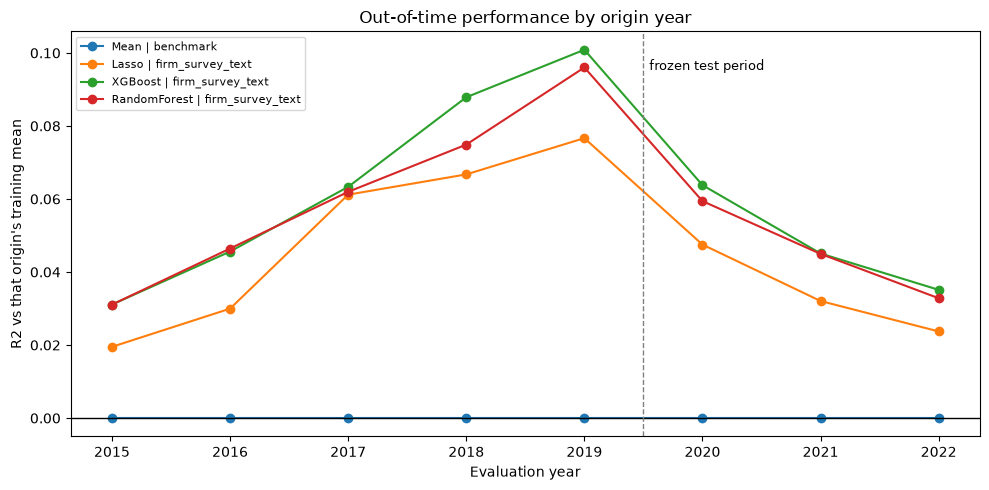

In [18]:
# Per-year RMSE, so regime shifts are visible rather than averaged away.
per_year_rows = []
for column in PREDICTION_COLS:
    model_name, set_name = column.split("__")
    for year, group in oos_predictions.groupby(YEAR_COL):
        metrics = regression_metrics(group["y"], group[column],
                                     float(group["origin_train_mean"].iloc[0]))
        per_year_rows.append({"model": model_name, "feature_set": set_name,
                              "year": int(year), **metrics})
per_year_results = pd.DataFrame(per_year_rows)
display(per_year_results.pivot_table(index="year", columns=["model", "feature_set"],
                                     values="RMSE").round(4))

headline = [c for c in PREDICTION_COLS if c.endswith("firm_survey_text") or c == "Mean__benchmark"]
fig, ax = plt.subplots(figsize=(10, 5))
for column in headline:
    series = per_year_results[
        (per_year_results["model"] == column.split("__")[0])
        & (per_year_results["feature_set"] == column.split("__")[1])].sort_values("year")
    ax.plot(series["year"], series["R2_oos"], marker="o", label=column.replace("__", " | "))
ax.axhline(0, color="black", linewidth=1)
ax.axvline(TEST_START_YEAR - 0.5, color="grey", linestyle="--", linewidth=1)
ax.text(TEST_START_YEAR - 0.45, ax.get_ylim()[1] * 0.9, "frozen test period", fontsize=9)
ax.set_xlabel("Evaluation year"); ax.set_ylabel("R2 vs that origin's training mean")
ax.set_title("Out-of-time performance by origin year")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

## 13. Inference: is any of this distinguishable from noise?

Diebold–Mariano tests on the loss differential, clustered on the evaluation year with a
`t(G-1)` reference distribution, plus a block bootstrap over years.

The previous version reported an XGBoost text contribution of −0.00032 RMSE as a finding. The
tests below establish whether differences of that magnitude are separable from sampling
variation. Both squared and absolute loss are tested, because they previously disagreed: no
model beat the mean benchmark on MAE.

In [19]:
def pairwise_comparison(reference_col, candidate_cols, frame, cluster_col=YEAR_COL,
                        n_boot=N_BOOTSTRAP):
    rows = []
    for column in candidate_cols:
        if column == reference_col:
            continue
        squared = diebold_mariano(frame["y"], frame[column], frame[reference_col],
                                  frame[cluster_col], loss="squared")
        absolute = diebold_mariano(frame["y"], frame[column], frame[reference_col],
                                   frame[cluster_col], loss="absolute")
        bootstrap = block_bootstrap_delta_rmse(frame["y"], frame[column], frame[reference_col],
                                               frame[cluster_col], n_boot=n_boot)
        rows.append({
            "candidate": column.replace("__", " | "),
            "dMSE": squared["mean_loss_differential"],
            "t_squared": squared["t_stat"],
            "p_squared": squared["p_value"],
            "dMAE": absolute["mean_loss_differential"],
            "p_absolute": absolute["p_value"],
            "dRMSE": bootstrap["delta_rmse"],
            "dRMSE_ci_low": bootstrap["ci_low"],
            "dRMSE_ci_high": bootstrap["ci_high"],
            "n_year_clusters": squared["n_groups"],
        })
    return pd.DataFrame(rows)


print("=" * 78)
print("A. Every model against the mean benchmark  (negative = model is better)")
print("=" * 78)
vs_benchmark = pairwise_comparison("Mean__benchmark",
                                   [c for c in PREDICTION_COLS if c != "Mean__benchmark"],
                                   oos_predictions)
display(vs_benchmark.sort_values("dRMSE").round(6))
vs_benchmark.to_csv(OUTPUT_DIR / "dm_tests_vs_benchmark.csv", index=False)

A. Every model against the mean benchmark  (negative = model is better)


,candidate,dMSE,t_squared,p_squared,dMAE,p_absolute,dRMSE,dRMSE_ci_low,dRMSE_ci_high,n_year_clusters
3,XGBoost | firm,-0.009742,-6.125139,0.000479,-0.004666,0.034139,-0.013025,-0.016695,-0.009344,8
4,RandomForest | firm,-0.009468,-5.982695,0.000552,-0.005309,0.017456,-0.012619,-0.016278,-0.008964,8
9,XGBoost | firm_survey_text,-0.008976,-5.900687,0.000599,-0.003923,0.071866,-0.012141,-0.015547,-0.008624,8
6,XGBoost | firm_survey,-0.008849,-5.734452,0.000710,-0.003826,0.068156,-0.011969,-0.015581,-0.008580,8
10,RandomForest | firm_survey_text,-0.008497,-6.209227,0.000441,-0.004540,0.029002,-0.011451,-0.014570,-0.008436,8
7,RandomForest | firm_survey,-0.008034,-5.560107,0.000851,-0.003774,0.074408,-0.010890,-0.014374,-0.007672,8
2,Lasso | firm,-0.007496,-6.268332,0.000417,-0.004473,0.013064,-0.009939,-0.012465,-0.007107,8
5,Lasso | firm_survey,-0.007044,-5.600595,0.000815,-0.003981,0.033140,-0.009488,-0.012175,-0.006503,8
8,Lasso | firm_survey_text,-0.006834,-5.187110,0.001271,-0.003691,0.050403,-0.009246,-0.012065,-0.006204,8
0,Zero growth | benchmark,0.002232,1.201296,0.268700,0.000835,0.663227,0.002849,-0.000824,0.006500,8


In [20]:
print("=" * 78)
print("B. The research question: does each information block add anything?")
print("   Each row compares a richer block against the next-poorer block, same model.")
print("=" * 78)

incremental_rows = []
for model_name in MODEL_FAMILIES:
    for richer, poorer, label in [("firm_survey", "firm", "survey indicators"),
                                  ("firm_survey_text", "firm_survey", "text indicators")]:
        richer_col, poorer_col = f"{model_name}__{richer}", f"{model_name}__{poorer}"
        if richer_col not in oos_predictions or poorer_col not in oos_predictions:
            continue
        squared = diebold_mariano(oos_predictions["y"], oos_predictions[richer_col],
                                  oos_predictions[poorer_col], oos_predictions[YEAR_COL])
        bootstrap = block_bootstrap_delta_rmse(oos_predictions["y"], oos_predictions[richer_col],
                                               oos_predictions[poorer_col],
                                               oos_predictions[YEAR_COL], n_boot=N_BOOTSTRAP)
        incremental_rows.append({
            "model": model_name, "increment": label,
            "dRMSE": bootstrap["delta_rmse"],
            "ci_low": bootstrap["ci_low"], "ci_high": bootstrap["ci_high"],
            "dMSE": squared["mean_loss_differential"],
            "t_stat": squared["t_stat"], "p_value": squared["p_value"],
            "years_favouring_richer": float(bootstrap["share_favouring_a"]),
            "n_year_clusters": squared["n_groups"],
        })

incremental_value = pd.DataFrame(incremental_rows)
display(incremental_value.round(6))
incremental_value.to_csv(OUTPUT_DIR / "incremental_information_value.csv", index=False)

print("\nInterpretation guide:")
print("  dRMSE < 0  the richer block forecasts better on average")
print("  The confidence interval is what matters. If it spans zero, the honest conclusion is")
print("  that the block has no detectable incremental value at this sample size - which is a")
print("  legitimate answer to RQ1, not a failure.")

significant = incremental_value[incremental_value["p_value"] < 0.05]
if significant.empty:
    print("\nRESULT: no information block shows a statistically detectable improvement")
    print(f"        at the 5% level with {int(incremental_value['n_year_clusters'].max())} year-clusters.")
else:
    print("\nBlocks with a detectable improvement at the 5% level:")
    display(significant.round(6))

B. The research question: does each information block add anything?
   Each row compares a richer block against the next-poorer block, same model.


,model,increment,dRMSE,ci_low,ci_high,dMSE,t_stat,p_value,years_favouring_richer,n_year_clusters
0,Lasso,survey indicators,0.000451,-0.000496,0.001942,0.000451,0.757958,0.473216,0.274,8
1,Lasso,text indicators,0.000242,-0.000035,0.000613,0.000210,1.404504,0.202953,0.054,8
2,XGBoost,survey indicators,0.001056,-0.000233,0.002698,0.000892,1.370058,0.212992,0.076,8
3,XGBoost,text indicators,-0.000172,-0.000631,0.000342,-0.000127,-0.601646,0.566377,0.698,8
4,RandomForest,survey indicators,0.001728,-0.000297,0.004398,0.001434,1.350852,0.218778,0.094,8
5,RandomForest,text indicators,-0.000561,-0.001681,0.000320,-0.000463,-1.107718,0.304589,0.872,8



Interpretation guide:
  dRMSE < 0  the richer block forecasts better on average
  The confidence interval is what matters. If it spans zero, the honest conclusion is
  that the block has no detectable incremental value at this sample size - which is a
  legitimate answer to RQ1, not a failure.

RESULT: no information block shows a statistically detectable improvement
        at the 5% level with 8 year-clusters.


In [21]:
# Power check: what effect size could this design have detected?
print("=" * 78)
print("C. Minimum detectable effect")
print("=" * 78)
power_rows = []
for model_name in MODEL_FAMILIES:
    poorer_col = f"{model_name}__firm"
    richer_col = f"{model_name}__firm_survey_text"
    if poorer_col not in oos_predictions or richer_col not in oos_predictions:
        continue
    differential = ((oos_predictions["y"] - oos_predictions[richer_col]) ** 2
                    - (oos_predictions["y"] - oos_predictions[poorer_col]) ** 2)
    year_means = differential.groupby(oos_predictions[YEAR_COL]).mean()
    n_groups = len(year_means)
    standard_error = float(year_means.std(ddof=1) / np.sqrt(n_groups))
    critical = float(stats.t.ppf(0.975, df=n_groups - 1))
    baseline_mse = float(np.mean((oos_predictions["y"] - oos_predictions["Mean__benchmark"]) ** 2))
    power_rows.append({
        "model": model_name,
        "observed_dMSE": float(year_means.mean()),
        "standard_error": standard_error,
        "min_detectable_dMSE": critical * standard_error,
        "min_detectable_as_share_of_benchmark_mse": critical * standard_error / baseline_mse,
        "n_year_clusters": n_groups,
    })
power = pd.DataFrame(power_rows)
display(power.round(6))
print("Read this as: with this many years of macro variation, only an improvement of at least")
print("the 'min_detectable' size could have been distinguished from zero. State it in the paper -")
print("it converts a null result from a weakness into a quantified statement about the design.")

C. Minimum detectable effect


,model,observed_dMSE,standard_error,min_detectable_dMSE,min_detectable_as_share_of_benchmark_mse,n_year_clusters
0,Lasso,0.000662,0.000585,0.001384,0.009279,8
1,XGBoost,0.000766,0.000548,0.001297,0.008698,8
2,RandomForest,0.000971,0.000698,0.001650,0.011066,8


Read this as: with this many years of macro variation, only an improvement of at least
the 'min_detectable' size could have been distinguished from zero. State it in the paper -
it converts a null result from a weakness into a quantified statement about the design.


## 14. RQ2 — does the predictive value vary across firm characteristics?

The previous version did not address RQ2: the proposed `sentiment_x_leverage` and
`sentiment_x_size` features were never added to any feature block, and no subgroup results
were reported.

Two complementary approaches here:

1. **Subgroup ablation.** Split the rolling-origin predictions by size, leverage and sector,
   and re-run the incremental-value comparison inside each group. This reuses the predictions
   already computed, so it costs nothing extra, and it has far more power than the pooled
   test: the macro state is held fixed within a year, so the *cross-sectional* contrast is
   identified off firm-level variation rather than off ten annual observations.
2. **Explicit interactions.** Add sentiment × firm-characteristic terms and test whether the
   interaction block improves on the full block. Trees can represent interactions in
   principle, but with only ~10 distinct sentiment values they rarely find them.

Tercile cut points are computed on the **development period only** and applied to evaluation
rows, so no test-period information defines the groups.

size tercile cut points (development period): [7.0623 8.6338]
leverage tercile cut points (development period): [0.4968 0.8062]

--- Lasso: value of survey+text over firm fundamentals, by size ---


,group,n,RMSE_poorer,RMSE_richer,dRMSE,ci_low,ci_high,p_value
0,small,30250,0.398962,0.399179,0.000217,-0.000358,0.000964,0.489072
1,medium,36581,0.371195,0.372099,0.000904,-0.000230,0.002928,0.288327
2,large,34170,0.360451,0.361380,0.000928,-0.000259,0.002739,0.279644



--- Lasso: value of survey+text over firm fundamentals, by leverage ---


,group,n,RMSE_poorer,RMSE_richer,dRMSE,ci_low,ci_high,p_value
0,low,35221,0.390005,0.390840,0.000834,-0.000240,0.002693,0.304122
1,mid,33495,0.364348,0.364832,0.000484,-0.000307,0.001687,0.340080
2,high,32285,0.372971,0.373716,0.000745,-0.000170,0.002195,0.257545



--- XGBoost: value of survey+text over firm fundamentals, by size ---


...

,group,n,RMSE_poorer,RMSE_richer,dRMSE,ci_low,ci_high,p_value
0,small,30250,0.397272,0.398052,0.000780,-0.001067,0.002665,0.456910
1,medium,36581,0.369003,0.370121,0.001118,-0.000644,0.003150,0.279904
2,large,34170,0.356251,0.357859,0.001609,0.000681,0.002692,0.031568



--- RandomForest: value of survey+text over firm fundamentals, by leverage ---


,group,n,RMSE_poorer,RMSE_richer,dRMSE,ci_low,ci_high,p_value
0,low,35221,0.387616,0.388797,0.001181,-0.000287,0.003004,0.242941
1,mid,33495,0.361770,0.363106,0.001335,-0.000310,0.003074,0.174071
2,high,32285,0.369852,0.370836,0.000983,-0.000488,0.002587,0.253516



--- XGBoost: value of survey+text by 2-digit sector (sectors with n >= 2,000) ---


,group,n,RMSE_poorer,RMSE_richer,dRMSE,ci_low,ci_high,p_value
21,72,2462,0.385354,0.385432,0.000077,-0.001662,0.002576,0.821467
19,62,5140,0.362797,0.363167,0.000370,-0.000564,0.001442,0.492468
14,53,8712,0.344348,0.344902,0.000554,-0.000142,0.001225,0.209986
3,23,12767,0.388360,0.388924,0.000564,-0.000682,0.001920,0.369050
10,48,4776,0.385867,0.386463,0.000596,-0.001067,0.002335,0.487107
17,56,7515,0.376496,0.377183,0.000688,-0.000399,0.001801,0.336996
5,32,3988,0.348546,0.349375,0.000829,-0.000344,0.002346,0.272052
15,54,10136,0.394574,0.395498,0.000924,-0.000203,0.002219,0.230456
2,22,3468,0.282437,0.283428,0.000990,0.000223,0.001703,0.058575
22,81,3126,0.372812,0.373842,0.001030,-0.001021,0.004380,0.417411


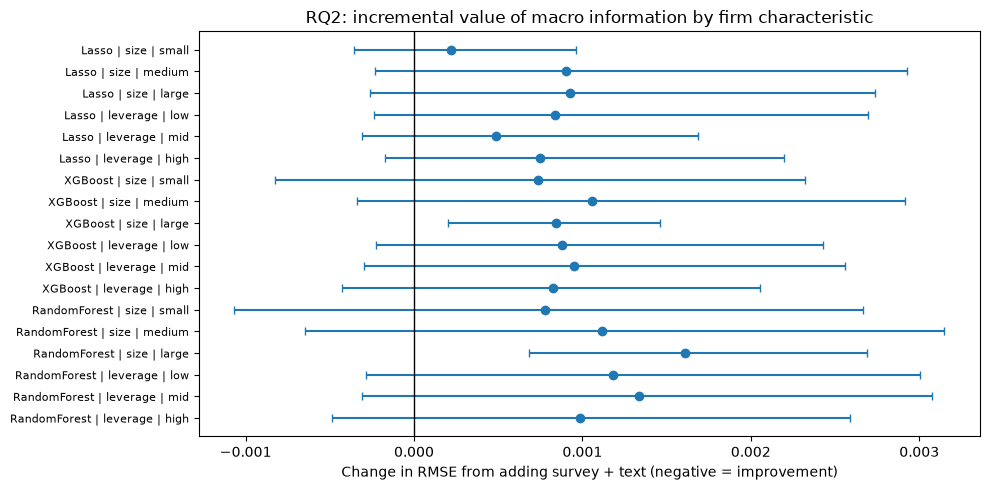

In [22]:
GROUPING_SPECS = [
    ("size", "log_toas", ["small", "medium", "large"]),
    ("leverage", "liabilities_to_assets", ["low", "mid", "high"]),
]

grouping_columns = list(dict.fromkeys(
    [c for _, c, _ in GROUPING_SPECS if c in df.columns]
    + (["naics_2digit"] if "naics_2digit" in df.columns else [])))
grouping_frame = df.loc[:, [ID_COL, YEAR_COL] + grouping_columns]
oos_grouped = oos_predictions.merge(grouping_frame, on=[ID_COL, YEAR_COL], how="left")

for group_name, column, labels in GROUPING_SPECS:
    if column not in oos_grouped.columns:
        continue
    cuts = np.unique(train_df[column].quantile([1 / 3, 2 / 3]).to_numpy())
    if len(cuts) < 2:
        print(f"{group_name}: degenerate tercile cut points, skipping.")
        continue
    oos_grouped[f"{group_name}_group"] = pd.cut(
        oos_grouped[column], bins=[-np.inf, *cuts, np.inf], labels=labels)
    print(f"{group_name} tercile cut points (development period): {np.round(cuts, 4)}")


def subgroup_incremental_value(frame, group_column, model_name,
                               richer="firm_survey_text", poorer="firm"):
    richer_col, poorer_col = f"{model_name}__{richer}", f"{model_name}__{poorer}"
    rows = []
    for group, part in frame.groupby(group_column, observed=True):
        if part[group_column].isna().all() or len(part) < 100:
            continue
        squared = diebold_mariano(part["y"], part[richer_col], part[poorer_col], part[YEAR_COL])
        bootstrap = block_bootstrap_delta_rmse(part["y"], part[richer_col], part[poorer_col],
                                               part[YEAR_COL], n_boot=N_BOOTSTRAP)
        rows.append({
            "group": str(group), "n": len(part),
            "RMSE_poorer": regression_metrics(part["y"], part[poorer_col], train_mean)["RMSE"],
            "RMSE_richer": regression_metrics(part["y"], part[richer_col], train_mean)["RMSE"],
            "dRMSE": bootstrap["delta_rmse"],
            "ci_low": bootstrap["ci_low"], "ci_high": bootstrap["ci_high"],
            "p_value": squared["p_value"],
        })
    return pd.DataFrame(rows)


subgroup_tables = {}
for model_name in MODEL_FAMILIES:
    for group_name, column, _ in GROUPING_SPECS:
        group_column = f"{group_name}_group"
        if group_column not in oos_grouped.columns:
            continue
        table = subgroup_incremental_value(oos_grouped, group_column, model_name)
        if table.empty:
            continue
        subgroup_tables[(model_name, group_name)] = table
        print(f"\n--- {model_name}: value of survey+text over firm fundamentals, by {group_name} ---")
        display(table.round(6))

if "naics_2digit" in oos_grouped.columns:
    sector_table = subgroup_incremental_value(oos_grouped, "naics_2digit", "XGBoost")
    sector_table = sector_table[sector_table["n"] >= 2000].sort_values("dRMSE")
    print("\n--- XGBoost: value of survey+text by 2-digit sector (sectors with n >= 2,000) ---")
    display(sector_table.round(6))
    sector_table.to_csv(OUTPUT_DIR / "rq2_sector_incremental_value.csv", index=False)

if subgroup_tables:
    combined = pd.concat(
        [t.assign(model=m, grouping=g) for (m, g), t in subgroup_tables.items()],
        ignore_index=True)
    combined.to_csv(OUTPUT_DIR / "rq2_subgroup_incremental_value.csv", index=False)

    fig, ax = plt.subplots(figsize=(10, 5))
    labels = combined["model"] + " | " + combined["grouping"] + " | " + combined["group"]
    positions = np.arange(len(combined))
    ax.errorbar(combined["dRMSE"], positions,
                xerr=[combined["dRMSE"] - combined["ci_low"],
                      combined["ci_high"] - combined["dRMSE"]],
                fmt="o", capsize=3)
    ax.axvline(0, color="black", linewidth=1)
    ax.set_yticks(positions); ax.set_yticklabels(labels, fontsize=8)
    ax.set_xlabel("Change in RMSE from adding survey + text (negative = improvement)")
    ax.set_title("RQ2: incremental value of macro information by firm characteristic")
    ax.invert_yaxis(); plt.tight_layout(); plt.show()

### 14.1 Explicit sentiment × firm-characteristic interactions

In [23]:
if INTERACTION_FEATURES:
    interaction_predictions = rolling_origin_predictions(
        eval_df, EVAL_YEARS, MODEL_FAMILIES,
        ["firm_survey_text_interactions"], BLOCK_PARAMETERS, verbose=False)

    merged = oos_predictions.merge(
        interaction_predictions[[ID_COL, YEAR_COL]
                                + [c for c in interaction_predictions.columns
                                   if c.endswith("interactions")]],
        on=[ID_COL, YEAR_COL], how="inner")

    interaction_rows = []
    for model_name in MODEL_FAMILIES:
        richer_col = f"{model_name}__firm_survey_text_interactions"
        poorer_col = f"{model_name}__firm_survey_text"
        if richer_col not in merged.columns:
            continue
        squared = diebold_mariano(merged["y"], merged[richer_col], merged[poorer_col],
                                  merged[YEAR_COL])
        bootstrap = block_bootstrap_delta_rmse(merged["y"], merged[richer_col],
                                               merged[poorer_col], merged[YEAR_COL],
                                               n_boot=N_BOOTSTRAP)
        interaction_rows.append({
            "model": model_name,
            "RMSE_without_interactions": regression_metrics(
                merged["y"], merged[poorer_col], train_mean)["RMSE"],
            "RMSE_with_interactions": regression_metrics(
                merged["y"], merged[richer_col], train_mean)["RMSE"],
            "dRMSE": bootstrap["delta_rmse"],
            "ci_low": bootstrap["ci_low"], "ci_high": bootstrap["ci_high"],
            "p_value": squared["p_value"],
        })
    interaction_value = pd.DataFrame(interaction_rows)
    display(interaction_value.round(6))
    interaction_value.to_csv(OUTPUT_DIR / "rq2_interaction_value.csv", index=False)
else:
    print("No interaction features were constructed - check SENTIMENT_ANCHORS in Section 5.6.")

,model,RMSE_without_interactions,RMSE_with_interactions,dRMSE,ci_low,ci_high,p_value
0,Lasso,0.376899,0.376899,-0.000000,-0.000002,0.000001,0.657354
1,XGBoost,0.374004,0.374664,0.000660,-0.000883,0.002868,0.472002
2,RandomForest,0.374694,0.374782,0.000088,-0.001228,0.001302,0.838772


## 15. Frozen held-out test (2020 onwards)

Run **once**, with the specification frozen at the end of Section 11, on the full data. This
reproduces the split the assignment asks for.

Two disciplines matter in how this is reported:

* The **CV-selected specification leads**. Reporting whichever row happens to win on the test
  set is selection on the held-out data, which is what the split exists to prevent.
* The **year-clustered tests here have only a handful of clusters** and are shown for
  completeness. The rolling-origin results in Section 13 are the ones with usable power.

The comparison between the subsampled and full-data test scores also checks the concern that
hyperparameters tuned at one sample size are applied at a much larger one.

In [24]:
final_results = pd.DataFrame()
final_predictions = pd.DataFrame()
fitted_models = {}

if RUN_FINAL_TEST:
    final_train = sample_firms_to_target(train_df, FINAL_ROWS_PER_YEAR)
    final_test = test_df
    print(f"Final training rows: {len(final_train):,} ({final_train[ID_COL].nunique():,} firms)")
    print(f"Final test rows: {len(final_test):,}, years {sorted(final_test[YEAR_COL].unique())}")

    final_mean = float(final_train[TARGET].mean())
    predictions_frame = pd.DataFrame({
        ID_COL: final_test[ID_COL].to_numpy(),
        YEAR_COL: final_test[YEAR_COL].to_numpy(),
        "y": final_test[TARGET].to_numpy(dtype=float),
    })
    for name, prediction in baseline_predictions(final_test, final_mean).items():
        predictions_frame[f"{name}__benchmark"] = prediction

    for set_name in ABLATION_SETS:
        feature_cols = FEATURE_SETS[set_name]
        for model_name in MODEL_FAMILIES:
            started = time.time()
            parameters = BLOCK_PARAMETERS[set_name][model_name]
            with warnings.catch_warnings():
                warnings.simplefilter("ignore", category=ConvergenceWarning)
                prediction, model = fit_predict(model_name, parameters, feature_cols,
                                                final_train, final_test)
            predictions_frame[f"{model_name}__{set_name}"] = np.asarray(prediction, dtype=float)
            if set_name == "firm_survey_text":
                fitted_models[model_name] = model
            else:
                del model
            print(f"  {model_name:13s} | {set_name:20s} | {time.time() - started:6.1f}s")
            gc.collect()

    final_predictions = predictions_frame
    final_cols = [c for c in final_predictions.columns if "__" in c]

    rows = []
    for column in final_cols:
        model_name, set_name = column.split("__")
        pooled = regression_metrics(final_predictions["y"], final_predictions[column],
                                    final_mean, years=final_predictions[YEAR_COL])
        rows.append({"scope": "pooled", "year": f"{min(TEST_YEARS)}-{max(TEST_YEARS)}",
                     "model": model_name, "feature_set": set_name, **pooled})
        for year, group in final_predictions.groupby(YEAR_COL):
            yearly = regression_metrics(group["y"], group[column], final_mean)
            rows.append({"scope": "year", "year": int(year), "model": model_name,
                         "feature_set": set_name, **yearly})
    final_results = pd.DataFrame(rows)
    final_results.to_csv(OUTPUT_DIR / "held_out_test_results.csv", index=False)
    final_predictions.to_parquet(OUTPUT_DIR / "held_out_test_predictions.parquet", index=False)

    print("\nPooled held-out results:")
    display(final_results[final_results["scope"].eq("pooled")]
            .sort_values("RMSE").reset_index(drop=True).round(5))
    print("\nBy year:")
    display(final_results[final_results["scope"].eq("year")]
            .pivot_table(index="year", columns=["model", "feature_set"], values="RMSE").round(4))
else:
    print("RUN_FINAL_TEST=False: the held-out data were not touched.")

Final training rows: 82,991 (18,547 firms)
Final test rows: 630,228, years [np.int64(2020), np.int64(2021), np.int64(2022)]
  Lasso         | firm                 |    1.2s
  XGBoost       | firm                 |    4.6s
  RandomForest  | firm                 |   13.5s
  Lasso         | firm_survey          |    1.7s
  XGBoost       | firm_survey          |    5.3s
  RandomForest  | firm_survey          |   14.6s
  Lasso         | firm_survey_text     |    1.8s
  XGBoost       | firm_survey_text     |    5.4s
  RandomForest  | firm_survey_text     |   12.0s

Pooled held-out results:


,scope,year,model,feature_set,RMSE,MAE,R2_oos,R2_oos_within_year,n
0,pooled,2020-2022,XGBoost,firm_survey_text,0.36937,0.27770,0.04546,0.03672,630228
1,pooled,2020-2022,RandomForest,firm_survey_text,0.36942,0.27649,0.04520,0.03646,630228
2,pooled,2020-2022,XGBoost,firm_survey,0.36983,0.27820,0.04308,0.03432,630228
3,pooled,2020-2022,RandomForest,firm_survey,0.37044,0.27789,0.03992,0.03113,630228
4,pooled,2020-2022,XGBoost,firm,0.37076,0.27931,0.03823,0.02942,630228
5,pooled,2020-2022,Lasso,firm,0.37113,0.27571,0.03631,0.02748,630228
6,pooled,2020-2022,Lasso,firm_survey,0.37126,0.27619,0.03566,0.02683,630228
7,pooled,2020-2022,RandomForest,firm,0.37129,0.27867,0.03548,0.02664,630228
8,pooled,2020-2022,Lasso,firm_survey_text,0.37224,0.27754,0.03053,0.02165,630228
9,pooled,2020-2022,Mean,benchmark,0.37806,0.27809,0.00000,-0.00916,630228



By year:


model         Lasso                                   Mean Persistence RandomForest                              XGBoost                              Zero growth
feature_set    firm firm_survey firm_survey_text benchmark   benchmark         firm firm_survey firm_survey_text    firm firm_survey firm_survey_text   benchmark
year                                                                                                                                                             
2020         0.3756      0.3755           0.3762    0.3853      0.5490       0.3741      0.3736           0.3732  0.3736      0.3732           0.3729      0.3851
2021         0.3720      0.3721           0.3727    0.3790      0.5286       0.3730      0.3722           0.3708  0.3724      0.3714           0.3714      0.3774
2022         0.3646      0.3651           0.3669    0.3681      0.5200       0.3658      0.3644           0.3632  0.3654      0.3638           0.3626      0.3706

In [25]:
if RUN_FINAL_TEST and not final_results.empty:
    # ---- The specification chosen on development-period CV, stated first --------
    dev_only = per_year_results[(per_year_results["year"] < TEST_START_YEAR)
                                & per_year_results["feature_set"].isin(ABLATION_SETS)]
    dev_ranking = (dev_only.groupby(["model", "feature_set"])["RMSE"].mean()
                   .sort_values().reset_index())
    print("Ranking on DEVELOPMENT-period origins only (this is the selection evidence):")
    display(dev_ranking.round(5))

    selected_model = dev_ranking.iloc[0]["model"]
    selected_block = dev_ranking.iloc[0]["feature_set"]
    selected_col = f"{selected_model}__{selected_block}"
    print(f"\nSpecification selected without seeing the test period: {selected_col}")

    pooled = final_results[final_results["scope"].eq("pooled")].set_index(
        ["model", "feature_set"])
    if (selected_model, selected_block) in pooled.index:
        row = pooled.loc[(selected_model, selected_block)]
        print(f"Its held-out performance: RMSE={row['RMSE']:.5f}, MAE={row['MAE']:.5f}, "
              f"R2_oos={row['R2_oos']:.5f}, R2_oos_within_year={row['R2_oos_within_year']:.5f}")
    best_test = pooled["RMSE"].idxmin()
    print(f"Best row on the test set: {best_test[0]} | {best_test[1]} "
          f"(RMSE={pooled['RMSE'].min():.5f})")
    if best_test != (selected_model, selected_block):
        print("\nThese differ. Report the CV-selected specification as the result and the")
        print("test-best row as an observation - choosing the latter is selection on held-out data.")

    # ---- Squared vs absolute loss ---------------------------------------------
    mean_mae = float(pooled.loc[("Mean", "benchmark"), "MAE"])
    beats_on_mae = pooled[(pooled.index.get_level_values(1) != "benchmark")
                          & (pooled["MAE"] < mean_mae)]
    print(f"\nMean-benchmark MAE: {mean_mae:.6f}")
    print(f"Models beating it on MAE: {len(beats_on_mae)} of "
          f"{len(pooled) - (pooled.index.get_level_values(1) == 'benchmark').sum()}")
    if beats_on_mae.empty:
        print("None. Every gain is under squared loss, i.e. from shrinking predictions away")
        print("from the tails rather than getting the typical firm right. Report both metrics.")

    # ---- Under-powered tests on the test block, shown for completeness ---------
    print(f"\nDiebold-Mariano on the held-out block ({len(TEST_YEARS)} year-clusters - "
          "under-powered by construction):")
    display(pairwise_comparison("Mean__benchmark",
                                [c for c in final_cols if c != "Mean__benchmark"],
                                final_predictions).round(6))

Ranking on DEVELOPMENT-period origins only (this is the selection evidence):


,model,feature_set,RMSE
0,XGBoost,firm,0.37828
1,RandomForest,firm,0.37861
2,XGBoost,firm_survey_text,0.38002
3,XGBoost,firm_survey,0.38028
4,RandomForest,firm_survey_text,0.38078
5,RandomForest,firm_survey,0.38175
6,Lasso,firm,0.38180
7,Lasso,firm_survey,0.38272
8,Lasso,firm_survey_text,0.38304



Specification selected without seeing the test period: XGBoost__firm
Its held-out performance: RMSE=0.37076, MAE=0.27931, R2_oos=0.03823, R2_oos_within_year=0.02942
Best row on the test set: XGBoost | firm_survey_text (RMSE=0.36937)

These differ. Report the CV-selected specification as the result and the
test-best row as an observation - choosing the latter is selection on held-out data.

Mean-benchmark MAE: 0.278094
Models beating it on MAE: 6 of 9

Diebold-Mariano on the held-out block (3 year-clusters - under-powered by construction):


,candidate,dMSE,t_squared,p_squared,dMAE,p_absolute,dRMSE,dRMSE_ci_low,dRMSE_ci_high,n_year_clusters
0,Zero growth | benchmark,0.000172,0.191450,0.865848,0.000492,0.782673,0.000086,-0.001582,0.002515,3
1,Persistence | benchmark,0.141215,24.097941,0.001718,0.116472,0.001482,0.155274,0.149660,0.163671,3
2,Lasso | firm,-0.005048,-3.571371,0.070242,-0.002190,0.368339,-0.006927,-0.009736,-0.003440,3
3,XGBoost | firm,-0.005283,-2.625594,0.119589,0.001476,0.658444,-0.007296,-0.011748,-0.002682,3
4,RandomForest | firm,-0.004894,-2.453808,0.133594,0.000833,0.794632,-0.006766,-0.011225,-0.002246,3
5,Lasso | firm_survey,-0.004943,-3.233068,0.083816,-0.001700,0.504951,-0.006803,-0.009816,-0.002984,3
6,XGBoost | firm_survey,-0.006002,-3.436082,0.075261,0.000309,0.901620,-0.008233,-0.012084,-0.004289,3
7,RandomForest | firm_survey,-0.005552,-3.081996,0.091118,0.000001,0.999790,-0.007623,-0.011706,-0.003685,3
8,Lasso | firm_survey_text,-0.004176,-2.363184,0.141915,-0.000295,0.918521,-0.005816,-0.009111,-0.001205,3
9,XGBoost | firm_survey_text,-0.006375,-3.988694,0.057488,-0.000265,0.910191,-0.008694,-0.012436,-0.005518,3


## 16. Model interpretation

Partial dependence is the addition that matters. Variable importance answers "*is* sentiment
used"; partial dependence answers "*how responsive* is predicted credit demand to sentiment",
which is what RQ1 actually asks. Both are covered in the lecture on ensembles.

Permutation importance is computed on a **development holdout (2019)**, not the test set, so
that this exploratory step does not consume the held-out data.

In [26]:
def manual_partial_dependence(model, X, feature, grid_values, predict_fn=None):
    """Average prediction as `feature` is swept, holding all other columns at observed values.

    Written manually rather than via sklearn so that pandas categorical dtypes and the
    XGBoost-native NaN handling both survive.
    """
    predict_fn = predict_fn or model.predict
    work = X.copy()
    original = work[feature].copy()
    means = []
    for value in grid_values:
        work[feature] = value
        means.append(float(np.mean(predict_fn(work))))
    work[feature] = original
    return pd.DataFrame({feature: grid_values, "partial_dependence": means})


def permutation_importance_manual(model, X, y, feature_cols, n_repeats=3,
                                  random_state=RANDOM_STATE, predict_fn=None):
    predict_fn = predict_fn or model.predict
    baseline = float(np.sqrt(np.mean((np.asarray(y, float) - predict_fn(X)) ** 2)))
    rng = np.random.default_rng(random_state)
    rows = []
    for feature in feature_cols:
        increases = []
        original = X[feature].copy()
        for _ in range(n_repeats):
            shuffled = original.to_numpy(copy=True)[rng.permutation(len(X))]
            # rebuild with the original dtype so categorical columns stay categorical
            X[feature] = pd.Series(shuffled, index=X.index).astype(original.dtype)
            increases.append(
                float(np.sqrt(np.mean((np.asarray(y, float) - predict_fn(X)) ** 2))) - baseline)
        X[feature] = original
        rows.append({"feature": feature,
                     "rmse_increase_mean": float(np.mean(increases)),
                     "rmse_increase_std": float(np.std(increases))})
    return (pd.DataFrame(rows).sort_values("rmse_increase_mean", ascending=False)
            .reset_index(drop=True)), baseline


# ---- Development holdout: train on <2019, interpret on 2019 -------------------
interpret_cols = FEATURE_SETS["firm_survey_text"]
interpret_train = tuning_df[tuning_df[YEAR_COL] < LAST_VALIDATION_YEAR]
interpret_holdout = tuning_df[tuning_df[YEAR_COL] == LAST_VALIDATION_YEAR]
interpret_params = BLOCK_PARAMETERS["firm_survey_text"]["XGBoost"]

_, interpret_model = fit_predict("XGBoost", interpret_params, interpret_cols,
                                 interpret_train, interpret_holdout)
levels = tree_category_levels(interpret_train, interpret_cols)
X_holdout = prepare_tree_frame(interpret_holdout, interpret_cols, levels)

sample_n = min(PERMUTATION_SAMPLE_SIZE, len(X_holdout))
X_permutation = X_holdout.sample(sample_n, random_state=RANDOM_STATE)
y_permutation = interpret_holdout.loc[X_permutation.index, TARGET]

permutation_table, baseline_rmse = permutation_importance_manual(
    interpret_model, X_permutation.copy(), y_permutation, interpret_cols,
    n_repeats=PERMUTATION_REPEATS)
print(f"Permutation importance on the {LAST_VALIDATION_YEAR} development holdout "
      f"(baseline RMSE {baseline_rmse:.5f}):")
display(permutation_table.head(25).round(6))
permutation_table.to_csv(OUTPUT_DIR / "permutation_importance_dev_holdout.csv", index=False)

gain = interpret_model.get_booster().get_score(importance_type="gain")
gain_table = (pd.DataFrame({"feature": list(gain), "gain": list(gain.values())})
              .sort_values("gain", ascending=False).reset_index(drop=True))
display(gain_table.head(25).round(3))
gain_table.to_csv(OUTPUT_DIR / "xgb_gain_importance.csv", index=False)

print("\nThe two rankings will disagree. Gain rewards features used in many splits; permutation")
print("measures predictive contribution and divides credit among correlated features - and the")
print("survey block contains ~40 collinear series, so each individually looks unimportant.")

Permutation importance on the 2019 development holdout (baseline RMSE 0.38459):


,feature,rmse_increase_mean,rmse_increase_std
0,ltdb_share_of_ncli,0.009132,0.000644
1,log1p_current_ratio_clean,0.005750,0.000095
2,log1p_quick_ratio_clean,0.001573,0.000013
3,fixed_assets_share,0.001519,0.000294
4,log_toas_change_clean,0.001147,0.000051
5,log_toas,0.001013,0.000069
6,ncliGrowthThisYear,0.000957,0.000106
7,firm_age,0.000418,0.000022
8,missing_log1p_current_ratio_clean,0.000387,0.000039
9,naics_2digit,0.000346,0.000086


,feature,gain
0,missing_log1p_quick_ratio_clean,39.050
1,missing_log1p_gearing_ratio_clean,36.696
2,missing_log1p_current_ratio_clean,24.253
3,log1p_current_ratio_clean,15.433
4,is_na_empl,9.245
5,lm_polarity,8.370
6,ltdb_share_of_ncli,7.060
7,log1p_quick_ratio_clean,7.026
8,uncertainty_ratio,6.376
9,missing_log_toas_change_clean,4.902



The two rankings will disagree. Gain rewards features used in many splits; permutation
measures predictive contribution and divides credit among correlated features - and the
survey block contains ~40 collinear series, so each individually looks unimportant.


### 16.1 Partial dependence — how responsive is predicted credit demand to sentiment?

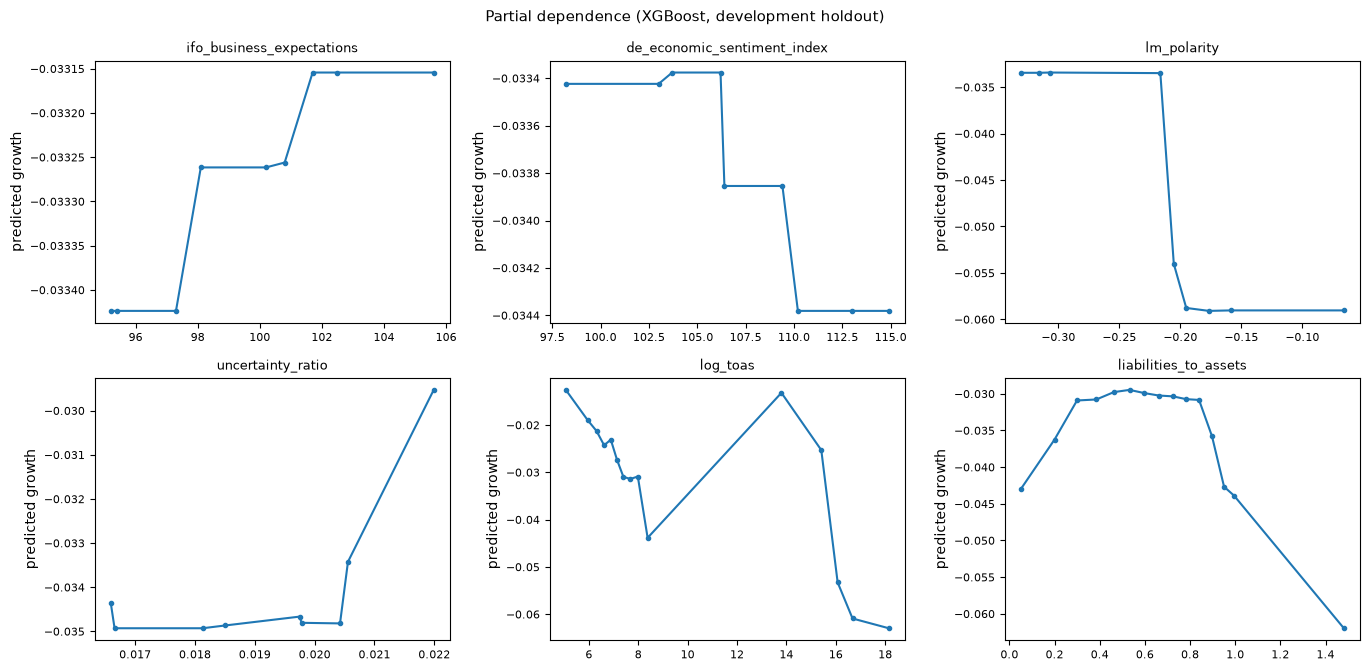

ifo_business_expectations                     partial-dependence range = 0.00027 ( 0.07% of one target SD)
de_economic_sentiment_index                   partial-dependence range = 0.00101 ( 0.25% of one target SD)
lm_polarity                                   partial-dependence range = 0.02566 ( 6.40% of one target SD)
uncertainty_ratio                             partial-dependence range = 0.00540 ( 1.35% of one target SD)
log_toas                                      partial-dependence range = 0.05039 (12.56% of one target SD)
liabilities_to_assets                         partial-dependence range = 0.03250 ( 8.10% of one target SD)

This range is the answer to 'how responsive is credit demand to expectations'.
Compare it with the target's standard deviation before calling any of it economically
meaningful. Interpretation is predictive, not causal.


In [27]:
pdp_sample_n = min(PDP_SAMPLE_SIZE, len(X_holdout))
X_pdp = X_holdout.sample(pdp_sample_n, random_state=RANDOM_STATE).copy()

pdp_features = [c for c in (SENTIMENT_ANCHORS
                            + [c for c in ["lm_polarity", "uncertainty_ratio"] if c in interpret_cols]
                            + ["log_toas", "liabilities_to_assets"])
                if c in interpret_cols]

pdp_tables = {}
for feature in pdp_features:
    observed = interpret_train[feature].dropna()
    if observed.empty:
        continue
    # Sentiment series take only a handful of annual values: use those, not a dense grid.
    grid_values = (np.sort(observed.unique()) if observed.nunique() <= 15
                   else np.unique(np.quantile(observed, np.linspace(0.02, 0.98, 15))))
    pdp_tables[feature] = manual_partial_dependence(interpret_model, X_pdp, feature, grid_values)

if pdp_tables:
    n_panels = len(pdp_tables)
    n_cols = min(3, n_panels)
    n_rows = int(np.ceil(n_panels / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.6 * n_cols, 3.4 * n_rows), squeeze=False)
    for ax, (feature, table) in zip(axes.ravel(), pdp_tables.items()):
        ax.plot(table[feature], table["partial_dependence"], marker="o", markersize=3)
        ax.set_title(feature, fontsize=9)
        ax.set_xlabel(""); ax.set_ylabel("predicted growth")
        ax.tick_params(labelsize=8)
    for ax in axes.ravel()[n_panels:]:
        ax.axis("off")
    fig.suptitle("Partial dependence (XGBoost, development holdout)", fontsize=11)
    plt.tight_layout(); plt.show()

    for feature, table in pdp_tables.items():
        span = table["partial_dependence"].max() - table["partial_dependence"].min()
        print(f"{feature:45s} partial-dependence range = {span:.5f} "
              f"({span / float(np.std(interpret_holdout[TARGET])) * 100:5.2f}% of one target SD)")
    print("\nThis range is the answer to 'how responsive is credit demand to expectations'.")
    print("Compare it with the target's standard deviation before calling any of it economically")
    print("meaningful. Interpretation is predictive, not causal.")

    pd.concat([t.assign(feature_name=f).rename(columns={f: "value"})
               for f, t in pdp_tables.items()], ignore_index=True).to_csv(
        OUTPUT_DIR / "partial_dependence.csv", index=False)

### 16.2 Linear coefficients (only if the model converged)

In [28]:
if RUN_FINAL_TEST and BEST_LINEAR_FAMILY in fitted_models:
    linear_model = fitted_models[BEST_LINEAR_FAMILY]
    estimator = linear_model.named_steps["model"]
    n_iter = int(np.max(np.atleast_1d(getattr(estimator, "n_iter_", 0))))
    converged = (BEST_LINEAR_FAMILY == "Ridge") or (n_iter < getattr(estimator, "max_iter", np.inf))

    if not converged:
        print("The final linear model did NOT converge - coefficients are not reported.")
        print("Increase max_iter or the penalty in Section 8 and re-run before interpreting.")
    else:
        names = linear_model.named_steps["preprocess"].get_feature_names_out()
        coefficient_table = (pd.DataFrame({"feature": names, "coefficient": estimator.coef_})
                             .assign(abs_coefficient=lambda x: x["coefficient"].abs())
                             .sort_values("abs_coefficient", ascending=False)
                             .reset_index(drop=True))
        display(coefficient_table.head(25).round(6))
        coefficient_table.to_csv(OUTPUT_DIR / "linear_coefficients.csv", index=False)
        print(f"\nNon-zero coefficients: {int((estimator.coef_ != 0).sum())} of {estimator.coef_.size}")
        print("Dummies are standardized in this version, so coefficient magnitudes are comparable")
        print("across numeric and categorical features (they were not previously).")

,feature,coefficient,abs_coefficient
0,num__missing_log1p_current_ratio_clean,-0.048458,0.048458
1,num__ltdb_share_of_ncli,-0.041725,0.041725
2,num__log1p_quick_ratio_clean,-0.021550,0.021550
3,num__lm_polarity,-0.010867,0.010867
4,num__missing_log_toas_change_clean,-0.010372,0.010372
5,num__fixed_assets_share,0.008450,0.008450
6,num__missing_log1p_quick_ratio_clean,-0.007870,0.007870
7,num__ifo_business_situation,-0.003573,0.003573
8,num__ncli_growth_volatility_3y,-0.002599,0.002599
9,num__de_consumer_confidence_change_clean,0.001505,0.001505



Non-zero coefficients: 10 of 100
Dummies are standardized in this version, so coefficient magnitudes are comparable
across numeric and categorical features (they were not previously).


## 17. Robustness

Three checks, each targeting a specific weakness of the headline design.

### 17.1 Alternative outcome: ΔNCLI scaled by lagged total assets

In [29]:
RUN_ALT_OUTCOME = True

if RUN_ALT_OUTCOME and ALT_TARGET in df.columns and df[ALT_TARGET].notna().any():
    alt_eval = eval_df[eval_df[ALT_TARGET].notna()].copy()
    print(f"Alternative-outcome sample: {len(alt_eval):,} rows")
    print(f"Target summary: mean={alt_eval[ALT_TARGET].mean():.5f}, "
          f"sd={alt_eval[ALT_TARGET].std():.5f}, "
          f"p01={alt_eval[ALT_TARGET].quantile(0.01):.4f}, "
          f"p99={alt_eval[ALT_TARGET].quantile(0.99):.4f}")

    alt_predictions = rolling_origin_predictions(
        alt_eval, EVAL_YEARS, ["XGBoost"], ABLATION_SETS, BLOCK_PARAMETERS,
        target=ALT_TARGET, verbose=False)

    alt_reference = float(alt_eval.loc[alt_eval[YEAR_COL] < EVAL_FIRST_YEAR, ALT_TARGET].mean())
    alt_rows = []
    for column in [c for c in alt_predictions.columns if "__" in c]:
        model_name, set_name = column.split("__")
        alt_rows.append({"model": model_name, "feature_set": set_name,
                         **regression_metrics(alt_predictions["y"], alt_predictions[column],
                                              alt_reference, years=alt_predictions[YEAR_COL])})
    display(pd.DataFrame(alt_rows).sort_values("RMSE").round(6))

    alt_incremental = []
    for richer, poorer, label in [("firm_survey", "firm", "survey"),
                                  ("firm_survey_text", "firm_survey", "text")]:
        richer_col, poorer_col = f"XGBoost__{richer}", f"XGBoost__{poorer}"
        bootstrap = block_bootstrap_delta_rmse(alt_predictions["y"], alt_predictions[richer_col],
                                               alt_predictions[poorer_col],
                                               alt_predictions[YEAR_COL], n_boot=N_BOOTSTRAP)
        squared = diebold_mariano(alt_predictions["y"], alt_predictions[richer_col],
                                  alt_predictions[poorer_col], alt_predictions[YEAR_COL])
        alt_incremental.append({"increment": label, **bootstrap, "p_value": squared["p_value"]})
    print("\nIncremental information value under the alternative outcome:")
    display(pd.DataFrame(alt_incremental).round(6))
    print("If the sign or significance flips relative to Section 13, the headline conclusion is")
    print("an artefact of the outcome definition, not a property of credit demand.")
else:
    print("Alternative outcome unavailable - skipping.")

Alternative-outcome sample: 84,768 rows
Target summary: mean=-0.02900, sd=0.18517, p01=-0.7914, p99=0.4783


,model,feature_set,RMSE,MAE,R2_oos,R2_oos_within_year,n
3,XGBoost,firm,0.171221,0.103582,0.094549,0.068993,73612
5,XGBoost,firm_survey_text,0.171658,0.103712,0.089916,0.064229,73612
4,XGBoost,firm_survey,0.171776,0.103879,0.088673,0.062951,73612
0,Mean,benchmark,0.179005,0.109836,0.010352,-0.017581,73612
1,Zero growth,benchmark,0.180241,0.104426,-0.003365,-0.031684,73612
2,Persistence,benchmark,0.409544,0.299851,-4.180266,-4.326477,73612



Incremental information value under the alternative outcome:


,increment,delta_rmse,ci_low,ci_high,share_favouring_a,n_groups,p_value
0,survey,0.000555,-0.000494,0.001596,0.236,8,0.415676
1,text,-0.000117,-0.000378,0.000172,0.724,8,0.865451


If the sign or significance flips relative to Section 13, the headline conclusion is
an artefact of the outcome definition, not a property of credit demand.


### 17.2 Robust loss functions

In [30]:
RUN_ROBUST_LOSS = True

if RUN_ROBUST_LOSS:
    robust_rows = []
    robust_objectives = {
        "squared error": "reg:squarederror",
        "absolute error": "reg:absoluteerror",
        "pseudo-Huber": "reg:pseudohubererror",
    }
    feature_cols = FEATURE_SETS["firm_survey_text"]
    base_parameters = dict(BLOCK_PARAMETERS["firm_survey_text"]["XGBoost"])

    for label, objective in robust_objectives.items():
        parameters = dict(base_parameters)
        parameters["objective"] = objective
        try:
            predictions = []
            for origin in EVAL_YEARS:
                origin_train = eval_df[(eval_df[YEAR_COL] < origin) & eval_df[TARGET].notna()]
                origin_score = eval_df[eval_df[YEAR_COL] == origin]
                if origin_train.empty or origin_score.empty:
                    continue
                prediction, model = fit_predict("XGBoost", parameters, feature_cols,
                                                origin_train, origin_score)
                predictions.append(pd.DataFrame({
                    YEAR_COL: origin, "y": origin_score[TARGET].to_numpy(float),
                    "pred": np.asarray(prediction, float)}))
                del model
                gc.collect()
            stacked = pd.concat(predictions, ignore_index=True)
            robust_rows.append({"loss": label,
                                **regression_metrics(stacked["y"], stacked["pred"],
                                                     reference_mean, years=stacked[YEAR_COL])})
        except Exception as error:  # objective may be unavailable in older xgboost
            print(f"  {label}: skipped ({type(error).__name__}: {error})")

    if robust_rows:
        display(pd.DataFrame(robust_rows).round(6))
        print("The mean benchmark previously beat every model on MAE. If a robust objective")
        print("closes that gap, report it: the loss function should match the decision the")
        print("bank is making, not be inherited from the default.")

,loss,RMSE,MAE,R2_oos,R2_oos_within_year,n
0,squared error,0.374004,0.281698,0.068514,0.051943,101001
1,absolute error,0.376408,0.278008,0.056503,0.039718,101001
2,pseudo-Huber,0.373990,0.280973,0.068585,0.052015,101001


The mean benchmark previously beat every model on MAE. If a robust objective
closes that gap, report it: the loss function should match the decision the
bank is making, not be inherited from the default.


### 17.3 Classification framing — which firms will demand credit?

In [31]:
RUN_CLASSIFICATION = True
CLASSIFICATION_THRESHOLD = 0.10   # "grew long-term liabilities by more than 10% next year"

if RUN_CLASSIFICATION:
    feature_cols_by_block = {name: FEATURE_SETS[name] for name in ABLATION_SETS}
    classification_rows = []

    for origin in EVAL_YEARS:
        origin_train = eval_df[(eval_df[YEAR_COL] < origin) & eval_df[TARGET].notna()]
        origin_score = eval_df[eval_df[YEAR_COL] == origin]
        if origin_train.empty or origin_score.empty:
            continue
        y_train = (origin_train[TARGET] > CLASSIFICATION_THRESHOLD).astype(int)
        y_score = (origin_score[TARGET] > CLASSIFICATION_THRESHOLD).astype(int)
        if y_score.nunique() < 2:
            continue

        for set_name, feature_cols in feature_cols_by_block.items():
            parameters = {k: v for k, v in BLOCK_PARAMETERS[set_name]["XGBoost"].items()
                          if k not in {"objective", "eval_metric"}}
            levels = tree_category_levels(origin_train, feature_cols)
            classifier = xgb.XGBClassifier(
                objective="binary:logistic", eval_metric="logloss", tree_method="hist",
                enable_categorical=True, random_state=RANDOM_STATE, n_jobs=N_JOBS, **parameters)
            classifier.fit(prepare_tree_frame(origin_train, feature_cols, levels), y_train)
            proba = classifier.predict_proba(
                prepare_tree_frame(origin_score, feature_cols, levels))[:, 1]

            decile = pd.qcut(pd.Series(proba).rank(method="first"), 10, labels=False)
            top_decile_rate = float(y_score.to_numpy()[np.asarray(decile) == 9].mean())
            base_rate = float(y_score.mean())
            classification_rows.append({
                "year": int(origin), "feature_set": set_name,
                "base_rate": base_rate,
                "AUC": float(roc_auc_score(y_score, proba)),
                "top_decile_rate": top_decile_rate,
                "lift": top_decile_rate / base_rate if base_rate > 0 else np.nan,
            })
            del classifier
            gc.collect()

    classification_results = pd.DataFrame(classification_rows)
    if not classification_results.empty:
        display(classification_results.round(4))
        summary = classification_results.groupby("feature_set").agg(
            mean_AUC=("AUC", "mean"), sd_AUC=("AUC", "std"),
            mean_lift=("lift", "mean"), n_years=("AUC", "size"))
        summary["AUC_ci_halfwidth"] = (
            stats.t.ppf(0.975, df=summary["n_years"] - 1)
            * summary["sd_AUC"] / np.sqrt(summary["n_years"]))
        display(summary.round(4))
        classification_results.to_csv(OUTPUT_DIR / "classification_results.csv", index=False)
        print("\nAUC and decile lift are far more informative for a bank planning financing")
        print("programmes than an R-squared of 0.04, and the ranking task is much less exposed")
        print("to the heavy tails of the growth variable. The confidence interval is computed")
        print("across evaluation years, so it reflects the same effective sample size as above.")

,year,feature_set,base_rate,AUC,top_decile_rate,lift
0,2015,firm,0.2687,0.6115,0.3909,1.4544
1,2015,firm_survey,0.2687,0.6090,0.3971,1.4776
2,2015,firm_survey_text,0.2687,0.6087,0.4012,1.4931
3,2016,firm,0.3157,0.6193,0.4349,1.3777
4,2016,firm_survey,0.3157,0.6196,0.4329,1.3713
5,2016,firm_survey_text,0.3157,0.6201,0.4400,1.3937
6,2017,firm,0.2595,0.6300,0.4046,1.5588
7,2017,firm_survey,0.2595,0.6256,0.4006,1.5436
8,2017,firm_survey_text,0.2595,0.6267,0.4046,1.5588
9,2018,firm,0.2661,0.6405,0.4136,1.5542


,mean_AUC,sd_AUC,mean_lift,n_years,AUC_ci_halfwidth
feature_set,,,,,
firm,0.6253,0.0124,1.4688,8,0.0104
firm_survey,0.6243,0.0126,1.4718,8,0.0106
firm_survey_text,0.6240,0.0121,1.4821,8,0.0102



AUC and decile lift are far more informative for a bank planning financing
programmes than an R-squared of 0.04, and the ranking task is much less exposed
to the heavy tails of the growth variable. The confidence interval is computed
across evaluation years, so it reflects the same effective sample size as above.


## 18. Text indicator diagnostics

Two checks the previous version did not run:

1. **How much independent variation is there?** The text series are annual, so the correlation
   matrix below has as many observations as there are years.
2. **External validity.** The Loughran–McDonald word lists were built on US 10-K filings and
   are applied here to Bundesbank prose. Correlating the constructed indicator with an
   independently validated series — the German Economic Policy Uncertainty index of Baker,
   Bloom & Davis — establishes whether it measures the intended construct. Drop that series in
   at the marked line if you obtain it.

Annual series: 14 observations. This is the effective sample size for every text-based claim in the paper.


,lm_polarity,uncertainty_ratio,litigious_ratio,constraining_ratio,strong_modal_ratio,weak_modal_ratio,ifo_business_climate,ifo_business_expectations,de_economic_sentiment_index
closdate_year,,,,,,,,,
2010,-0.3307,0.0198,0.0151,0.0074,0.0015,0.0046,103.000000,105.599998,113.000000
2011,-0.3071,0.0181,0.0149,0.0111,0.0010,0.0043,98.099998,95.400002,103.699997
2012,-0.0660,0.0197,0.0150,0.0044,0.0015,0.0046,95.400002,95.199997,98.199997
2013,-0.2164,0.0166,0.0189,0.0111,0.0010,0.0040,100.400002,101.699997,106.199997
2014,-0.2054,0.0206,0.0146,0.0038,0.0020,0.0062,98.199997,98.099998,103.000000
2015,-0.1952,0.0185,0.0337,0.0147,0.0016,0.0046,100.699997,100.800003,106.400002
2016,-0.3158,0.0220,0.0126,0.0055,0.0021,0.0056,101.000000,100.199997,109.400002
2017,-0.1589,0.0167,0.0158,0.0062,0.0021,0.0043,104.699997,102.500000,114.900002
2018,-0.1766,0.0204,0.0120,0.0063,0.0025,0.0043,101.199997,97.300003,110.199997



Correlation of text indicators with survey indicators (n = 14 years):


,ifo_business_climate,ifo_business_expectations,de_economic_sentiment_index
lm_polarity,0.435,0.384,0.098
uncertainty_ratio,-0.602,-0.624,-0.562
litigious_ratio,0.070,0.202,-0.081
constraining_ratio,-0.025,0.111,-0.140
strong_modal_ratio,0.093,-0.030,0.168
weak_modal_ratio,-0.128,-0.202,-0.186


High correlations mean the text block is largely redundant with the survey block,
which would explain a near-zero incremental contribution in Section 13.


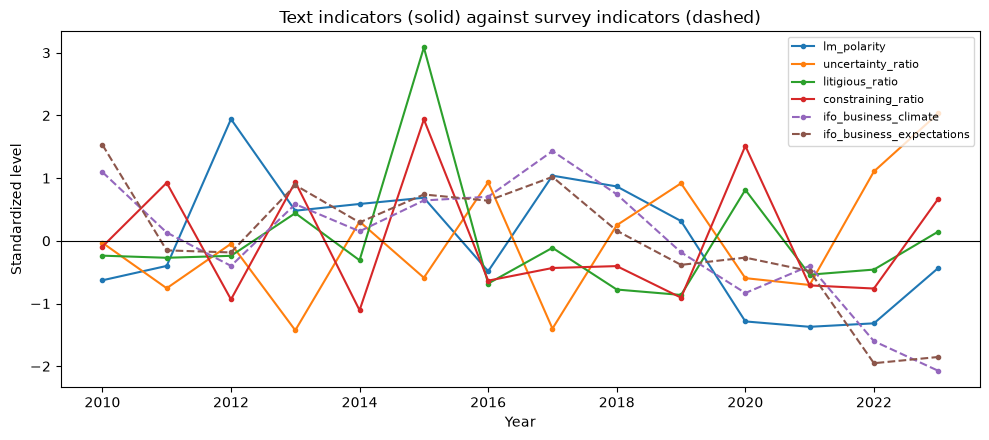


No external index supplied. Set EXTERNAL_INDEX_PATH to validate the constructed
indicator against the German EPU index (Baker, Bloom & Davis) - a short paragraph on
construct validity is worth more than another model in the deep dive.


In [32]:
text_columns = [c for c in TEXT_FEATURES if c in df.columns]
survey_columns = [c for c in ["ifo_business_climate", "ifo_business_expectations",
                              "de_economic_sentiment_index"] if c in df.columns]

if text_columns:
    annual_text = df.groupby(YEAR_COL)[text_columns + survey_columns].median(numeric_only=True)
    print(f"Annual series: {annual_text.shape[0]} observations. "
          "This is the effective sample size for every text-based claim in the paper.")
    display(annual_text.round(4))

    if survey_columns:
        correlations = annual_text.corr().loc[text_columns, survey_columns]
        print("\nCorrelation of text indicators with survey indicators "
              f"(n = {annual_text.shape[0]} years):")
        display(correlations.round(3))
        print("High correlations mean the text block is largely redundant with the survey block,")
        print("which would explain a near-zero incremental contribution in Section 13.")

    standardized = (annual_text - annual_text.mean()) / annual_text.std()
    fig, ax = plt.subplots(figsize=(10, 4.5))
    for column in text_columns[:4] + survey_columns[:2]:
        style = "--" if column in survey_columns else "-"
        ax.plot(standardized.index, standardized[column], style, marker="o",
                markersize=3, label=column)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xlabel("Year"); ax.set_ylabel("Standardized level")
    ax.set_title("Text indicators (solid) against survey indicators (dashed)")
    ax.legend(fontsize=8); plt.tight_layout(); plt.show()

# ---- External validation slot ------------------------------------------------
EXTERNAL_INDEX_PATH = None   # e.g. Path("data/external/de_epu_annual.csv") with columns year,value
if EXTERNAL_INDEX_PATH is not None and Path(EXTERNAL_INDEX_PATH).exists():
    external = pd.read_csv(EXTERNAL_INDEX_PATH).set_index("year")["value"]
    joined = annual_text.join(external.rename("external_index"), how="inner")
    print(f"\nCorrelation with the external index (n = {len(joined)} years):")
    display(joined.corr()["external_index"].drop("external_index").round(3))
else:
    print("\nNo external index supplied. Set EXTERNAL_INDEX_PATH to validate the constructed")
    print("indicator against the German EPU index (Baker, Bloom & Davis) - a short paragraph on")
    print("construct validity is worth more than another model in the deep dive.")

## 19. Sensitivity: remove calendar-time proxies

`years_in_panel` and the first-year missing indicators are near-deterministic functions of when
a firm entered the panel, and panel entry rates drift strongly with coverage. A model can use
them to encode *which year it is*, and that relationship does not extrapolate. If the headline
result changes materially when they are removed, the original number was partly an artefact of
the panel's construction rather than a property of credit demand.

In [33]:
if TIME_PROXY_FEATURES:
    sensitivity_sets = {
        f"{name}_no_time_proxy": [c for c in FEATURE_SETS[name] if c not in TIME_PROXY_FEATURES]
        for name in ABLATION_SETS
    }
    FEATURE_SETS.update(sensitivity_sets)
    for name in sensitivity_sets:
        BLOCK_PARAMETERS[name] = BLOCK_PARAMETERS[name.replace("_no_time_proxy", "")]

    sensitivity_predictions = rolling_origin_predictions(
        eval_df, EVAL_YEARS, ["XGBoost"], list(sensitivity_sets), BLOCK_PARAMETERS, verbose=False)

    rows = []
    for set_name in ABLATION_SETS:
        with_proxy = oos_predictions[f"XGBoost__{set_name}"]
        without_proxy = sensitivity_predictions[f"XGBoost__{set_name}_no_time_proxy"]
        rows.append({
            "feature_set": set_name,
            "RMSE_with_time_proxies": regression_metrics(
                oos_predictions["y"], with_proxy, reference_mean)["RMSE"],
            "RMSE_without_time_proxies": regression_metrics(
                sensitivity_predictions["y"], without_proxy, reference_mean)["RMSE"],
        })
    sensitivity = pd.DataFrame(rows)
    sensitivity["difference"] = (sensitivity["RMSE_without_time_proxies"]
                                 - sensitivity["RMSE_with_time_proxies"])
    display(sensitivity.round(6))
    sensitivity.to_csv(OUTPUT_DIR / "time_proxy_sensitivity.csv", index=False)

    print(f"\nRemoved: {TIME_PROXY_FEATURES}")
    print("A large positive difference means the calendar-time proxies were carrying real")
    print("predictive weight - which is a warning about the panel, not a modelling success.")
else:
    print("No calendar-time proxies flagged.")

,feature_set,RMSE_with_time_proxies,RMSE_without_time_proxies,difference
0,firm,0.373120,0.373251,0.000131
1,firm_survey,0.374176,0.374304,0.000128
2,firm_survey_text,0.374004,0.374274,0.000270



Removed: ['years_in_panel', 'missing_ncliGrowthThisYear', 'missing_log_toas_change_clean', 'missing_cash_change_to_lagged_assets', 'missing_ncli_growth_volatility_3y']
A large positive difference means the calendar-time proxies were carrying real
predictive weight - which is a warning about the panel, not a modelling success.


## 20. Save configuration and fitted models

In [34]:
configuration = {
    "data_path": str(DATA_PATH),
    "quick_mode": QUICK_MODE,
    "random_state": RANDOM_STATE,
    "winsor_quantiles": [WINSOR_LOWER, WINSOR_UPPER],
    "test_start_year": TEST_START_YEAR,
    "test_years": [int(y) for y in TEST_YEARS],
    "evaluation_years": [int(y) for y in EVAL_YEARS],
    "thin_years_excluded": [int(y) for y in THIN_YEARS],
    "validation_years": [int(y) for y in cv_years],
    "min_year_observations": MIN_YEAR_OBSERVATIONS,
    "screen_rows_per_year": SCREEN_ROWS_PER_YEAR,
    "tuning_rows_per_year": TUNING_ROWS_PER_YEAR,
    "eval_rows_per_year": EVAL_ROWS_PER_YEAR,
    "final_rows_per_year": FINAL_ROWS_PER_YEAR,
    "retune_per_block": RETUNE_PER_BLOCK,
    "rf_backend": RF_BACKEND,
    "selected_linear_family": BEST_LINEAR_FAMILY,
    "block_parameters": BLOCK_PARAMETERS,
    "feature_sets": FEATURE_SETS,
    "time_proxy_features": TIME_PROXY_FEATURES,
    "missing_indicators": MISSING_INDICATORS,
    "interaction_features": INTERACTION_FEATURES,
    "classification_threshold": CLASSIFICATION_THRESHOLD,
}
with open(OUTPUT_DIR / "run_configuration.json", "w", encoding="utf-8") as file:
    json.dump(configuration, file, indent=2, default=float)

if SAVE_MODELS and fitted_models:
    import joblib
    for name, model in fitted_models.items():
        if name == BEST_LINEAR_FAMILY:
            joblib.dump(model, OUTPUT_DIR / f"{name}_full_features.joblib")
        else:
            model.save_model(OUTPUT_DIR / f"{name}_full_features.json")

print(f"Outputs written to: {OUTPUT_DIR.resolve()}")
for path in sorted(OUTPUT_DIR.iterdir()):
    print(f"  {path.name}")

Outputs written to: /workspaces/MLforEcon/outputs/time_aware_model_report_v3
  classification_results.csv
  dm_tests_vs_benchmark.csv
  frozen_specification.json
  held_out_test_predictions.parquet
  held_out_test_results.csv
  incremental_information_value.csv
  linear_coefficients.csv
  partial_dependence.csv
  permutation_importance_dev_holdout.csv
  rolling_origin_predictions.parquet
  rolling_origin_summary.csv
  rq2_interaction_value.csv
  rq2_sector_incremental_value.csv
  rq2_subgroup_incremental_value.csv
  run_configuration.json
  time_proxy_sensitivity.csv
  xgb_gain_importance.csv


## 21. Reporting sequence

Present the results in this order. The order is the argument.

**Executive summary (2 pages)**
1. The forecasting task, the split, and the benchmark.
2. Headline: what the best model achieves out of time, in RMSE, MAE and both R² variants.
3. The answer to RQ1, with its confidence interval and the minimum detectable effect. If the
   interval spans zero, say so plainly — a quantified null is a result.
4. The answer to RQ2 from the subgroup tables, which have more power than the pooled test.
5. Limitations: publication lag, the ±100% trim on the outcome, coverage growth, and the fact
   that the macro information set has ~10 independent observations.

**Deep dive (15 slides)**
1. Data and panel structure (Section 4) — firm counts, coverage growth, missingness drift.
2. Feature construction and the leakage controls (Sections 5–6) — in-fold winsorization,
   shared missing indicators, the forbidden-feature guard.
3. Validation design (Section 7) — expanding folds, why rolling origin, why the test block is
   touched once.
4. Tuning (Sections 10–11) — the 1-SE rule, the boundary checks, and the flatness of the CV
   surface.
5. Benchmarks (Section 9) — including the mean-reverting outcome that sinks the persistence
   forecast.
6. Rolling-origin results (Section 12) — pooled and by year.
7. **Inference (Section 13)** — this is the slide that distinguishes the report. Diebold–Mariano
   with year clusters, bootstrap intervals, minimum detectable effect.
8. RQ2 (Section 14) — subgroup incremental value with intervals.
9. Frozen held-out block (Section 15) — CV-selected specification first, test-best row as an
   observation.
10. Interpretation (Section 16) — partial dependence for the magnitude of the sentiment
    response, importance rankings as description only.
11. Robustness (Section 17) — alternative outcome, robust loss, classification framing.
12. Text validity (Section 18).
13. Sensitivity to calendar-time proxies (Section 19).
14. Conclusions for NRW.BANK: what is forecastable, at what horizon, with what uncertainty.
15. What would move the needle: more macro history, real-time filing vintages, firm-level
    survey linkage.

### One discipline to hold
Once Section 15 has been executed, the specification is spent. Any further iteration should use
2019 as an internal pseudo-test and leave the 2020-onwards block alone. If you do change
something afterwards, say so in the paper — that transparency costs less than the alternative.